# Phase 5: GARCH Volatility Modeling

Implement GARCH(1,1) to model conditional volatility and detect market regimes using quantile-based classification.

## Steps:
1. Load best subset features (2000-2020) and prepare market returns and raw volatility
2. Fit GARCH(1,1) model and analyze volatility persistence (α + β, half-life)
3. Perform diagnostic tests (Ljung-Box, Jarque-Bera) and compare with GARCH(2,1)
4. Extract conditional volatility and classify into 3 regimes using quantile thresholds (33rd, 67th percentiles): Calm, Moderate, Turbulent
5. Visualize regime timeline and distribution across full period (2000-2020)
6. Deep dive into 2008 Financial Crisis: regime transitions and crisis period visualization
7. Full period analysis (2000-2020): regime statistics, transition matrix, and dotcom bubble validation
8. Generate 30-day forward volatility forecast using GARCH(1,1)
9. Save GARCH regimes and transition matrix for ensemble framework

In [52]:
from pathlib import Path
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
from scipy import stats
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

# Add project root to path
sys.path.append(str(Path('..').resolve()))

# Import GARCH model functions
from src.models.garch.garch_model import (
    fit_garch,
    extract_conditional_volatility,
    compute_persistence,
    forecast_volatility
)

# Import regime analysis functions
from src.utils.analysis.regime_analysis import (
    compute_transition_matrix,
    compute_regime_statistics,
    compute_persistence_metrics,
    classify_regimes_by_quantiles
)

# Import visualization functions
from src.utils.visualization.visualization import (
    plot_regime_timeline,
    plot_regime_distribution_bar,
    plot_regime_distribution_box,
    plot_transition_matrix_heatmap,
    plot_crisis_period
)

## 1. Data Loading and Preparation


In [53]:
# Load and clean best subset features
file_path = Path('../data/processed/best_subset_features.csv')
df_features = pd.read_csv(file_path, index_col=0, parse_dates=True)
df_features = df_features.drop(columns=['market_correlation'], errors='ignore')
df_features = df_features.dropna()
df_features = df_features[df_features.index >= '2000-01-01']

# Extract returns and volatility for modeling
market_returns = df_features['market_direction'].copy()
raw_vol_file = Path('../data/processed/market_volatility.csv')
if raw_vol_file.exists():
    raw_vol_df = pd.read_csv(raw_vol_file, index_col=0, parse_dates=True)
    common_dates = df_features.index.intersection(raw_vol_df.index)
    market_volatility = raw_vol_df.loc[common_dates, 'market_volatility'].copy()
else:
    market_volatility = df_features['market_volatility'].copy()
    print("Warning: Using z-scored volatility")

market_returns = market_returns.dropna()
market_volatility = market_volatility.dropna()

df_features.head()

,market_direction,market_volume,market_volatility,market_breadth,market_atr,Subset_Trend_PC1,Subset_Stress_PC2,Subset_Risk_Score
Date,,,,,,,,
2000-01-03,-1.551414,1.636506,0.678487,-1.249470,-1.402368,-1.704894,-1.109407,0.595487
2000-01-04,-1.633181,0.352394,1.226712,-0.758418,-1.442602,-1.572710,-0.530942,1.041768
2000-01-05,0.316822,-0.120482,0.711577,0.581008,-1.440025,0.735443,-0.144293,-0.879737
2000-01-06,-0.155672,-0.359724,0.906522,0.212651,-1.549435,0.375569,-0.928347,-1.303916
2000-01-07,1.836591,0.412224,1.519269,1.420245,-1.251777,2.225257,0.816114,-1.409142


### Dataset Summary

The analysis is conducted on *5,094 daily observations* spanning from *January 3, 2000 to April 1, 2020*.  
Market returns and volatility series are fully aligned after removing missing values.

#### Features Used
•⁠  ⁠Market direction  
•⁠  ⁠Market volume  
•⁠  ⁠Market volatility  
•⁠  ⁠Market breadth  
•⁠  ⁠Market ATR (average true range)  
•⁠  ⁠Subset trend (PC1)  
•⁠  ⁠Subset stress (PC2)

#### Descriptive Statistics

| Variable          | Observations | Mean     | Std. Dev. |
|-------------------|-------------:|---------:|----------:|
| Returns           | 5,094        | -0.0248  | 1.0758    |
| Volatility        | 5,094        | 0.0376   | 0.0207    |

All features are standardized to ensure comparability across indicators and to prevent scale effects during model estimation.

## 2. Model Configuration and Training

GARCH models capture volatility clustering.

**Model specification:**
- Returns: r_t = mu + epsilon_t
- Variance: sigma_t^2 = omega + alpha*epsilon_{t-1}^2 + beta*sigma_{t-1}^2

**Key metrics:**
- alpha: sensitivity to recent shocks
- beta: persistence of past volatility
- alpha + beta: overall persistence (close to 1 = high persistence)


### 2.1. Fit GARCH(1,1) Model


In [54]:
# Fit GARCH(1,1) model to market returns
garch_model, garch_results = fit_garch(market_returns, p=1, q=1)

# Display model summary
print("GARCH(1,1) Model Summary")
print(garch_results.summary())


GARCH(1,1) Model Summary
                     Constant Mean - GARCH Model Results                      
Dep. Variable:       market_direction   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -30482.4
Distribution:                  Normal   AIC:                           60972.8
Method:            Maximum Likelihood   BIC:                           60998.9
                                        No. Observations:                 5094
Date:                Mon, Dec 22 2025   Df Residuals:                     5093
Time:                        00:51:02   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             2.2283      1.261      1.767  

/opt/homebrew/Caskroom/miniconda/base/envs/ada/lib/python3.13/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 1.157e+04. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


### 2.2. Analyze Volatility Persistence

Compute persistence metrics from GARCH coefficients to quantify volatility clustering strength.


In [55]:
# Compute persistence metrics
persistence_metrics = compute_persistence(garch_results)

print("Volatility Persistence Metrics")
print(f"Alpha (ARCH coefficient):     {persistence_metrics['alpha']:.6f}")
print(f"Beta (GARCH coefficient):     {persistence_metrics['beta']:.6f}")
print(f"Persistence (alpha + beta):   {persistence_metrics['persistence']:.6f}")
print(f"Half-life (days):             {persistence_metrics['half_life']:.2f}")
print(f"Is stationary:                {persistence_metrics['is_stationary']}")

# Interpretation
if persistence_metrics['persistence'] >= 0.99:
    print("\nInterpretation: Very high persistence - volatility shocks decay extremely slowly")
elif persistence_metrics['persistence'] >= 0.95:
    print("\nInterpretation: High persistence - volatility clustering is strong")
elif persistence_metrics['persistence'] >= 0.90:
    print("\nInterpretation: Moderate persistence - typical for financial markets")
else:
    print("\nInterpretation: Low persistence - volatility shocks decay quickly")


Volatility Persistence Metrics
Alpha (ARCH coefficient):     0.114110
Beta (GARCH coefficient):     0.858520
Persistence (alpha + beta):   0.972629
Half-life (days):             24.98
Is stationary:                True

Interpretation: High persistence - volatility clustering is strong


### Volatility Persistence Results

The GARCH(1,1) estimation yields alpha = 0.114 and beta = 0.858, resulting in a persistence measure alpha + beta = 0.973. The implied half-life of volatility shocks is approximately 25 days, and the stationarity condition alpha + beta < 1 is satisfied.

These results indicate high volatility persistence, meaning that shocks to volatility decay slowly and tend to cluster over time. The dominance of the GARCH term suggests that past volatility is the main driver of current risk.

### 2.3. Diagnostic Tests and Model Selection

Test alternative GARCH specifications and validate model assumptions through residual diagnostics.

In [56]:
# Test GARCH(2,1) for comparison
print("\nTesting GARCH(2,1) for comparison")

garch_21_model, garch_21_results = fit_garch(market_returns, p=2, q=1)
std_resid_21 = garch_21_results.std_resid

lb_test_21 = acorr_ljungbox(std_resid_21, lags=[10, 20], return_df=True)
print("\nGARCH(2,1) Ljung-Box Test:")
print(lb_test_21)

# Compare models
print("\nModel Comparison:")
print(f"GARCH(1,1) - AIC: {garch_results.aic:.2f}, BIC: {garch_results.bic:.2f}")
print(f"GARCH(2,1) - AIC: {garch_21_results.aic:.2f}, BIC: {garch_21_results.bic:.2f}")

# Compute persistence for GARCH(2,1)
persistence_21 = compute_persistence(garch_21_results)
print(f"\nGARCH(2,1) Persistence:")
print(f"  Alpha[1]: {garch_21_results.params['alpha[1]']:.6f}")
print(f"  Alpha[2]: {garch_21_results.params['alpha[2]']:.6f}")
print(f"  Beta[1]:  {garch_21_results.params['beta[1]']:.6f}")
print(f"  Total:    {persistence_21['persistence']:.6f}")
print(f"  Half-life: {persistence_21['half_life']:.2f} days")

if garch_21_results.aic < garch_results.aic and lb_test_21['lb_pvalue'].min() > 0.05:
    print("\nGARCH(2,1) improves fit - consider using this specification")
else:
    print("\nGARCH(1,1) is adequate - no significant improvement from additional parameters")


Testing GARCH(2,1) for comparison

GARCH(2,1) Ljung-Box Test:
      lb_stat  lb_pvalue
10  30.310115   0.000762
20  45.145498   0.001054

Model Comparison:
GARCH(1,1) - AIC: 60972.76, BIC: 60998.91
GARCH(2,1) - AIC: 60970.38, BIC: 61003.06

GARCH(2,1) Persistence:
  Alpha[1]: 0.083684
  Alpha[2]: 0.040820
  Beta[1]:  0.844119
  Total:    0.927803
  Half-life: 9.25 days

GARCH(1,1) is adequate - no significant improvement from additional parameters


/opt/homebrew/Caskroom/miniconda/base/envs/ada/lib/python3.13/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 1.157e+04. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


### Diagnostic Tests and Model Comparison

To assess whether a more flexible specification improves model fit, a *GARCH(2,1)* model is estimated and compared to the baseline *GARCH(1,1)* model.

#### Residual Diagnostics (Ljung–Box Test)

The Ljung–Box test on standardized residuals for the GARCH(2,1) model yields statistically significant results at both tested lags:

| Lag | Test Statistic | p-value |
|----:|---------------:|--------:|
| 10  | 30.31          | 0.00076 |
| 20  | 45.15          | 0.00105 |

This indicates remaining autocorrelation in the residuals, suggesting that increasing model complexity does not fully resolve serial dependence.

#### Model Comparison

| Model      | AIC     | BIC     |
|------------|--------:|--------:|
| GARCH(1,1) | 60972.76 | 60998.91 |
| GARCH(2,1) | 60970.38 | 61003.06 |

While the GARCH(2,1) model achieves a slightly lower AIC, it is penalized by a higher BIC due to the additional parameter, indicating no clear overall improvement in model quality.

#### Volatility Persistence (GARCH(2,1))

•⁠  ⁠alpha_1 = 0.084  
•⁠  ⁠alpha_2 = 0.041  
•⁠  ⁠beta_1  = 0.844  
•⁠  ⁠Total persistence = 0.928  
•⁠  ⁠Half-life ≈ 9.3 days  

The persistence remains high but is *lower than in the GARCH(1,1) model*, implying faster decay of volatility shocks.

#### Conclusion

Overall, the additional ARCH term in the GARCH(2,1) specification does *not provide a significant improvement* in diagnostics or information criteria. Given its parsimony and comparable performance, *GARCH(1,1) is retained as the preferred model*.

In [57]:
# Extract standardized residuals
std_resid = garch_results.std_resid

lb_test = acorr_ljungbox(std_resid, lags=[10, 20], return_df=True)
print("Ljung-Box Test for Standardized Residuals")
print(lb_test)

lb_test_sq = acorr_ljungbox(std_resid**2, lags=[10, 20], return_df=True)
print("\nLjung-Box Test for Squared Standardized Residuals")
print(lb_test_sq)

jb_stat, jb_pvalue = jarque_bera(std_resid)
print(f"\nJarque-Bera Test for Normality")
print(f"Test statistic: {jb_stat:.4f}")
print(f"P-value: {jb_pvalue:.4f}")

Ljung-Box Test for Standardized Residuals
      lb_stat  lb_pvalue
10  29.454182   0.001052
20  43.926428   0.001539

Ljung-Box Test for Squared Standardized Residuals
      lb_stat  lb_pvalue
10   9.129423   0.519867
20  17.064882   0.648757

Jarque-Bera Test for Normality
Test statistic: 566.2649
P-value: 0.0000


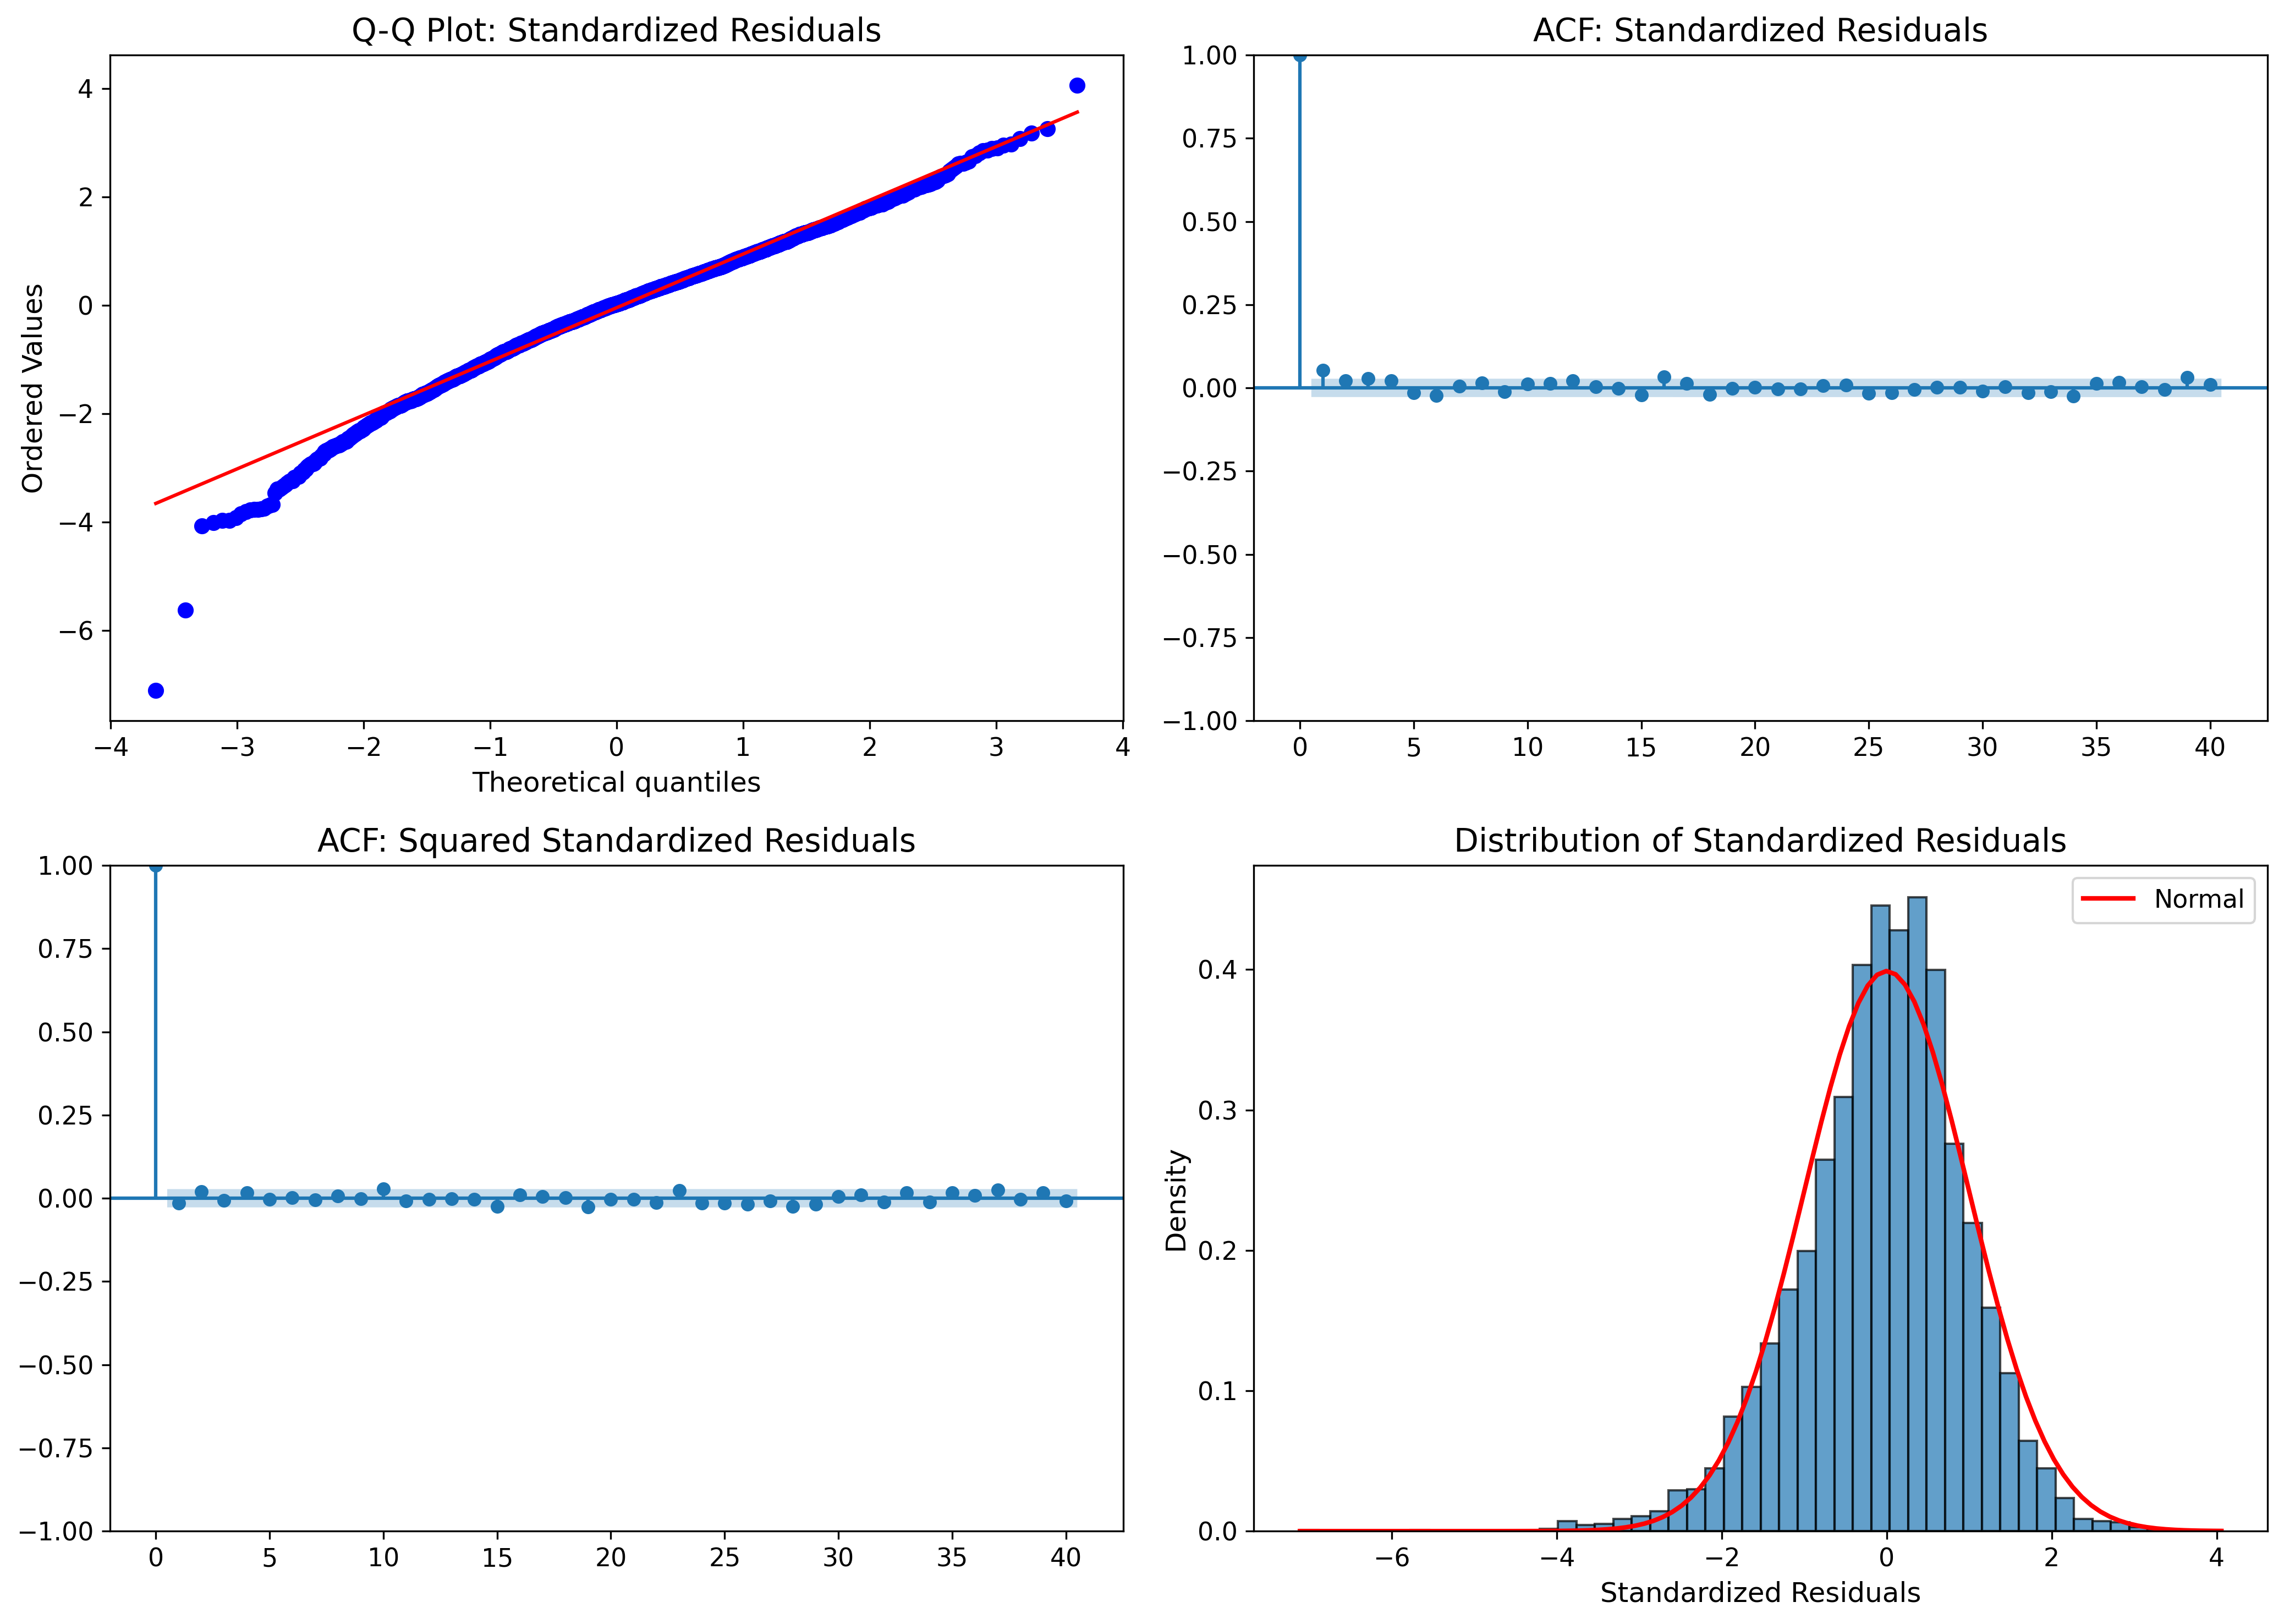

In [58]:
# Plot diagnostics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# QQ plot
stats.probplot(std_resid, dist="norm", plot=axes[0, 0])
axes[0, 0].set_title('Q-Q Plot: Standardized Residuals')

# ACF of residuals
plot_acf(std_resid, lags=40, ax=axes[0, 1], alpha=0.05)
axes[0, 1].set_title('ACF: Standardized Residuals')

# ACF of squared residuals
plot_acf(std_resid**2, lags=40, ax=axes[1, 0], alpha=0.05)
axes[1, 0].set_title('ACF: Squared Standardized Residuals')

# Histogram
axes[1, 1].hist(std_resid, bins=50, density=True, alpha=0.7, edgecolor='black')
x = np.linspace(std_resid.min(), std_resid.max(), 100)
axes[1, 1].plot(x, stats.norm.pdf(x), 'r-', linewidth=2, label='Normal')
axes[1, 1].set_xlabel('Standardized Residuals')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('Distribution of Standardized Residuals')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('../results/figures/garch_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

**Model Selection:** GARCH(1,1) is adequate. GARCH(2,1) adds complexity without meaningful improvement (marginal AIC gain but worse BIC).

## 3. Regime Timeline Visualization (2000-2020)

Classify conditional volatility into discrete regimes and visualize the timeline across major market events.


### 3.1. Quantile-Based Regime Classification

Convert continuous GARCH conditional volatility into discrete regimes using quantile thresholds.

**Method:**
- **Calm**: volatility below 33rd percentile
- **Moderate**: volatility between 33rd and 67th percentiles
- **Turbulent**: volatility above 67th percentile

This creates comparable regimes to HMM and K-means for ensemble analysis.


In [59]:
# Extract conditional volatility from GARCH model
garch_cond_vol = extract_conditional_volatility(garch_results)



# Classify into regimes using quantiles
result = classify_regimes_by_quantiles(garch_cond_vol, quantiles=(0.33, 0.67))
garch_regimes = pd.Series(result['regimes'], index=garch_cond_vol.index)
thresholds = result['thresholds']
regime_labels = result['regime_labels']



# Compute regime statistics
garch_regime_stats = compute_regime_statistics(garch_cond_vol, garch_regimes, regime_labels)


### 3.2. Regime Timeline Plot

Visualize regime evolution over the full period (2000-2020) with quantile thresholds.


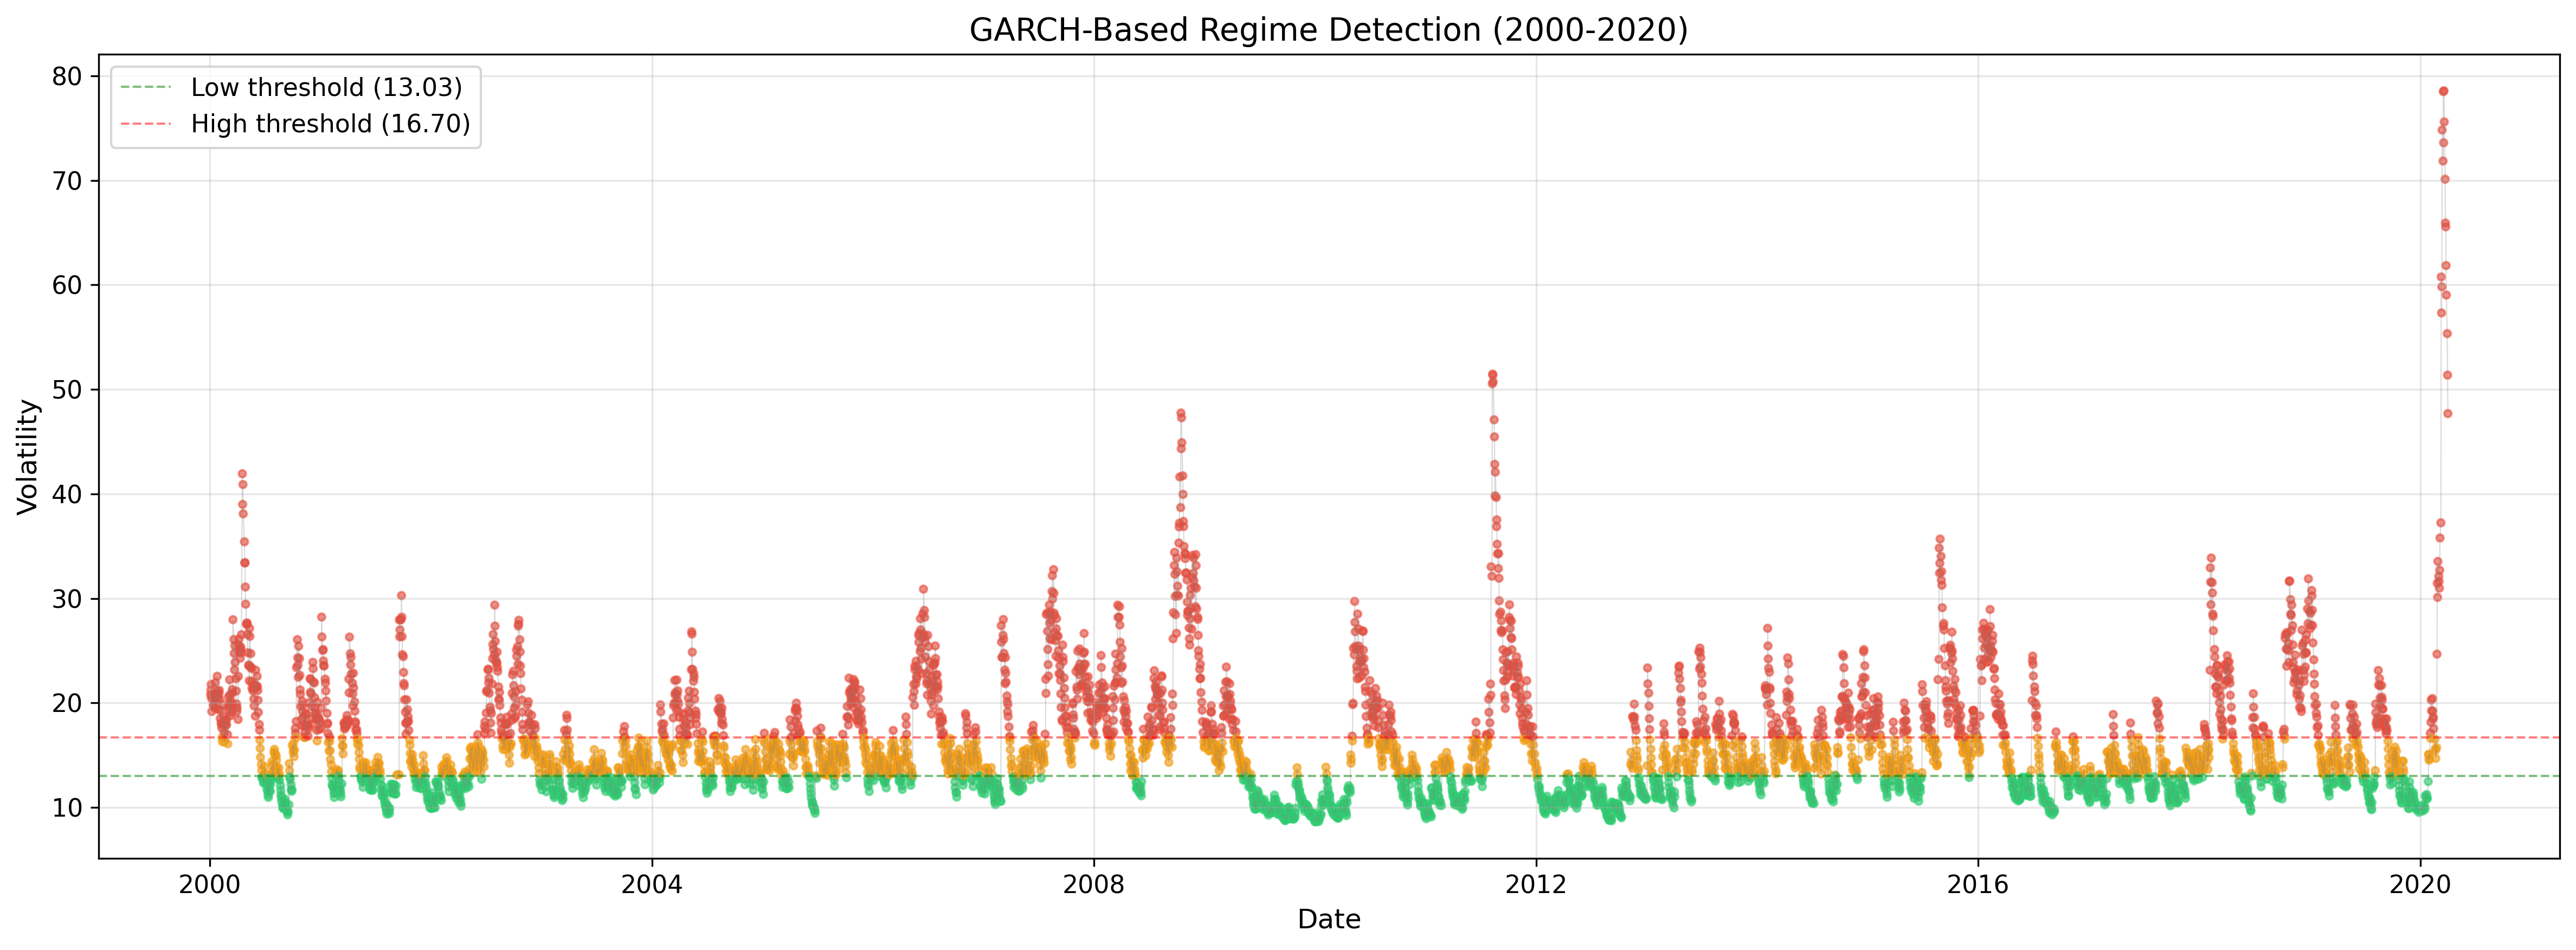

In [60]:
plot_regime_timeline(
    dates=garch_regimes.index,
    regimes=garch_regimes.values,
    volatility=garch_cond_vol.values,
    thresholds=thresholds,
    title='GARCH-Based Regime Detection (2000-2020)',
    save_path='../results/figures/garch_regime_timeline.png',
    figsize=(16, 6)
)

### 3.3. Regime Distribution

Visualize the distribution of regimes and volatility characteristics for each state.


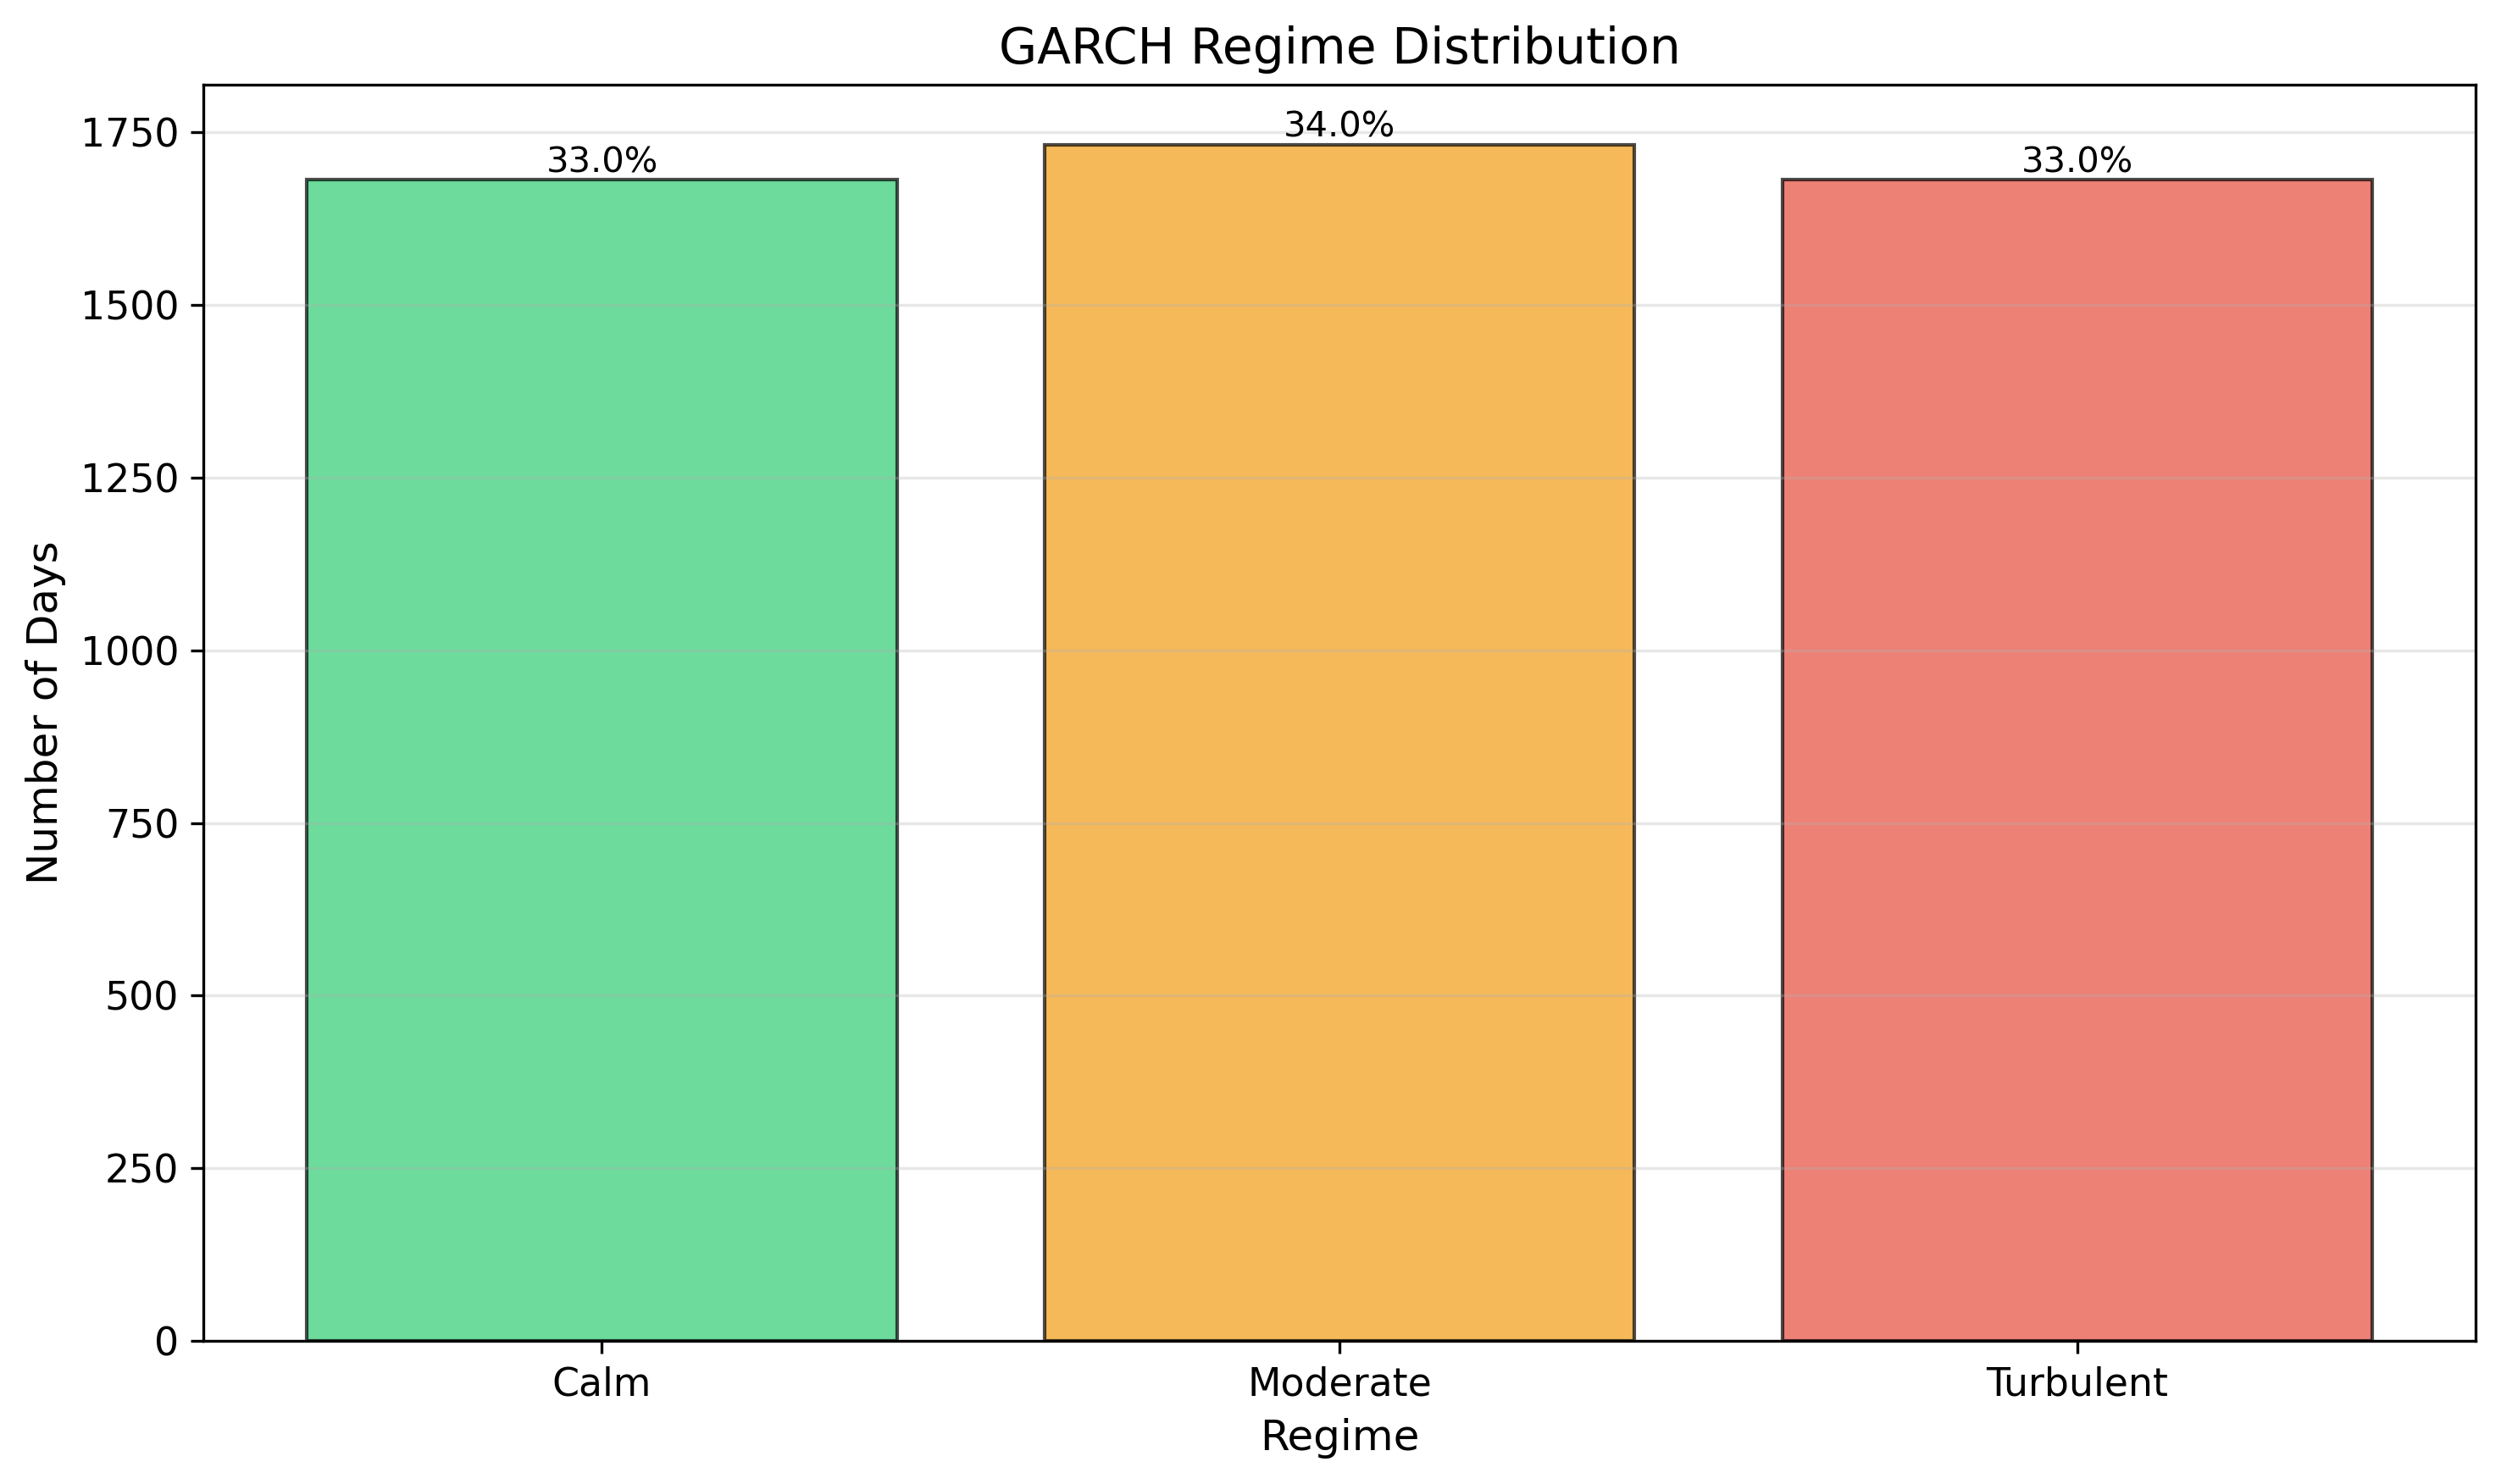

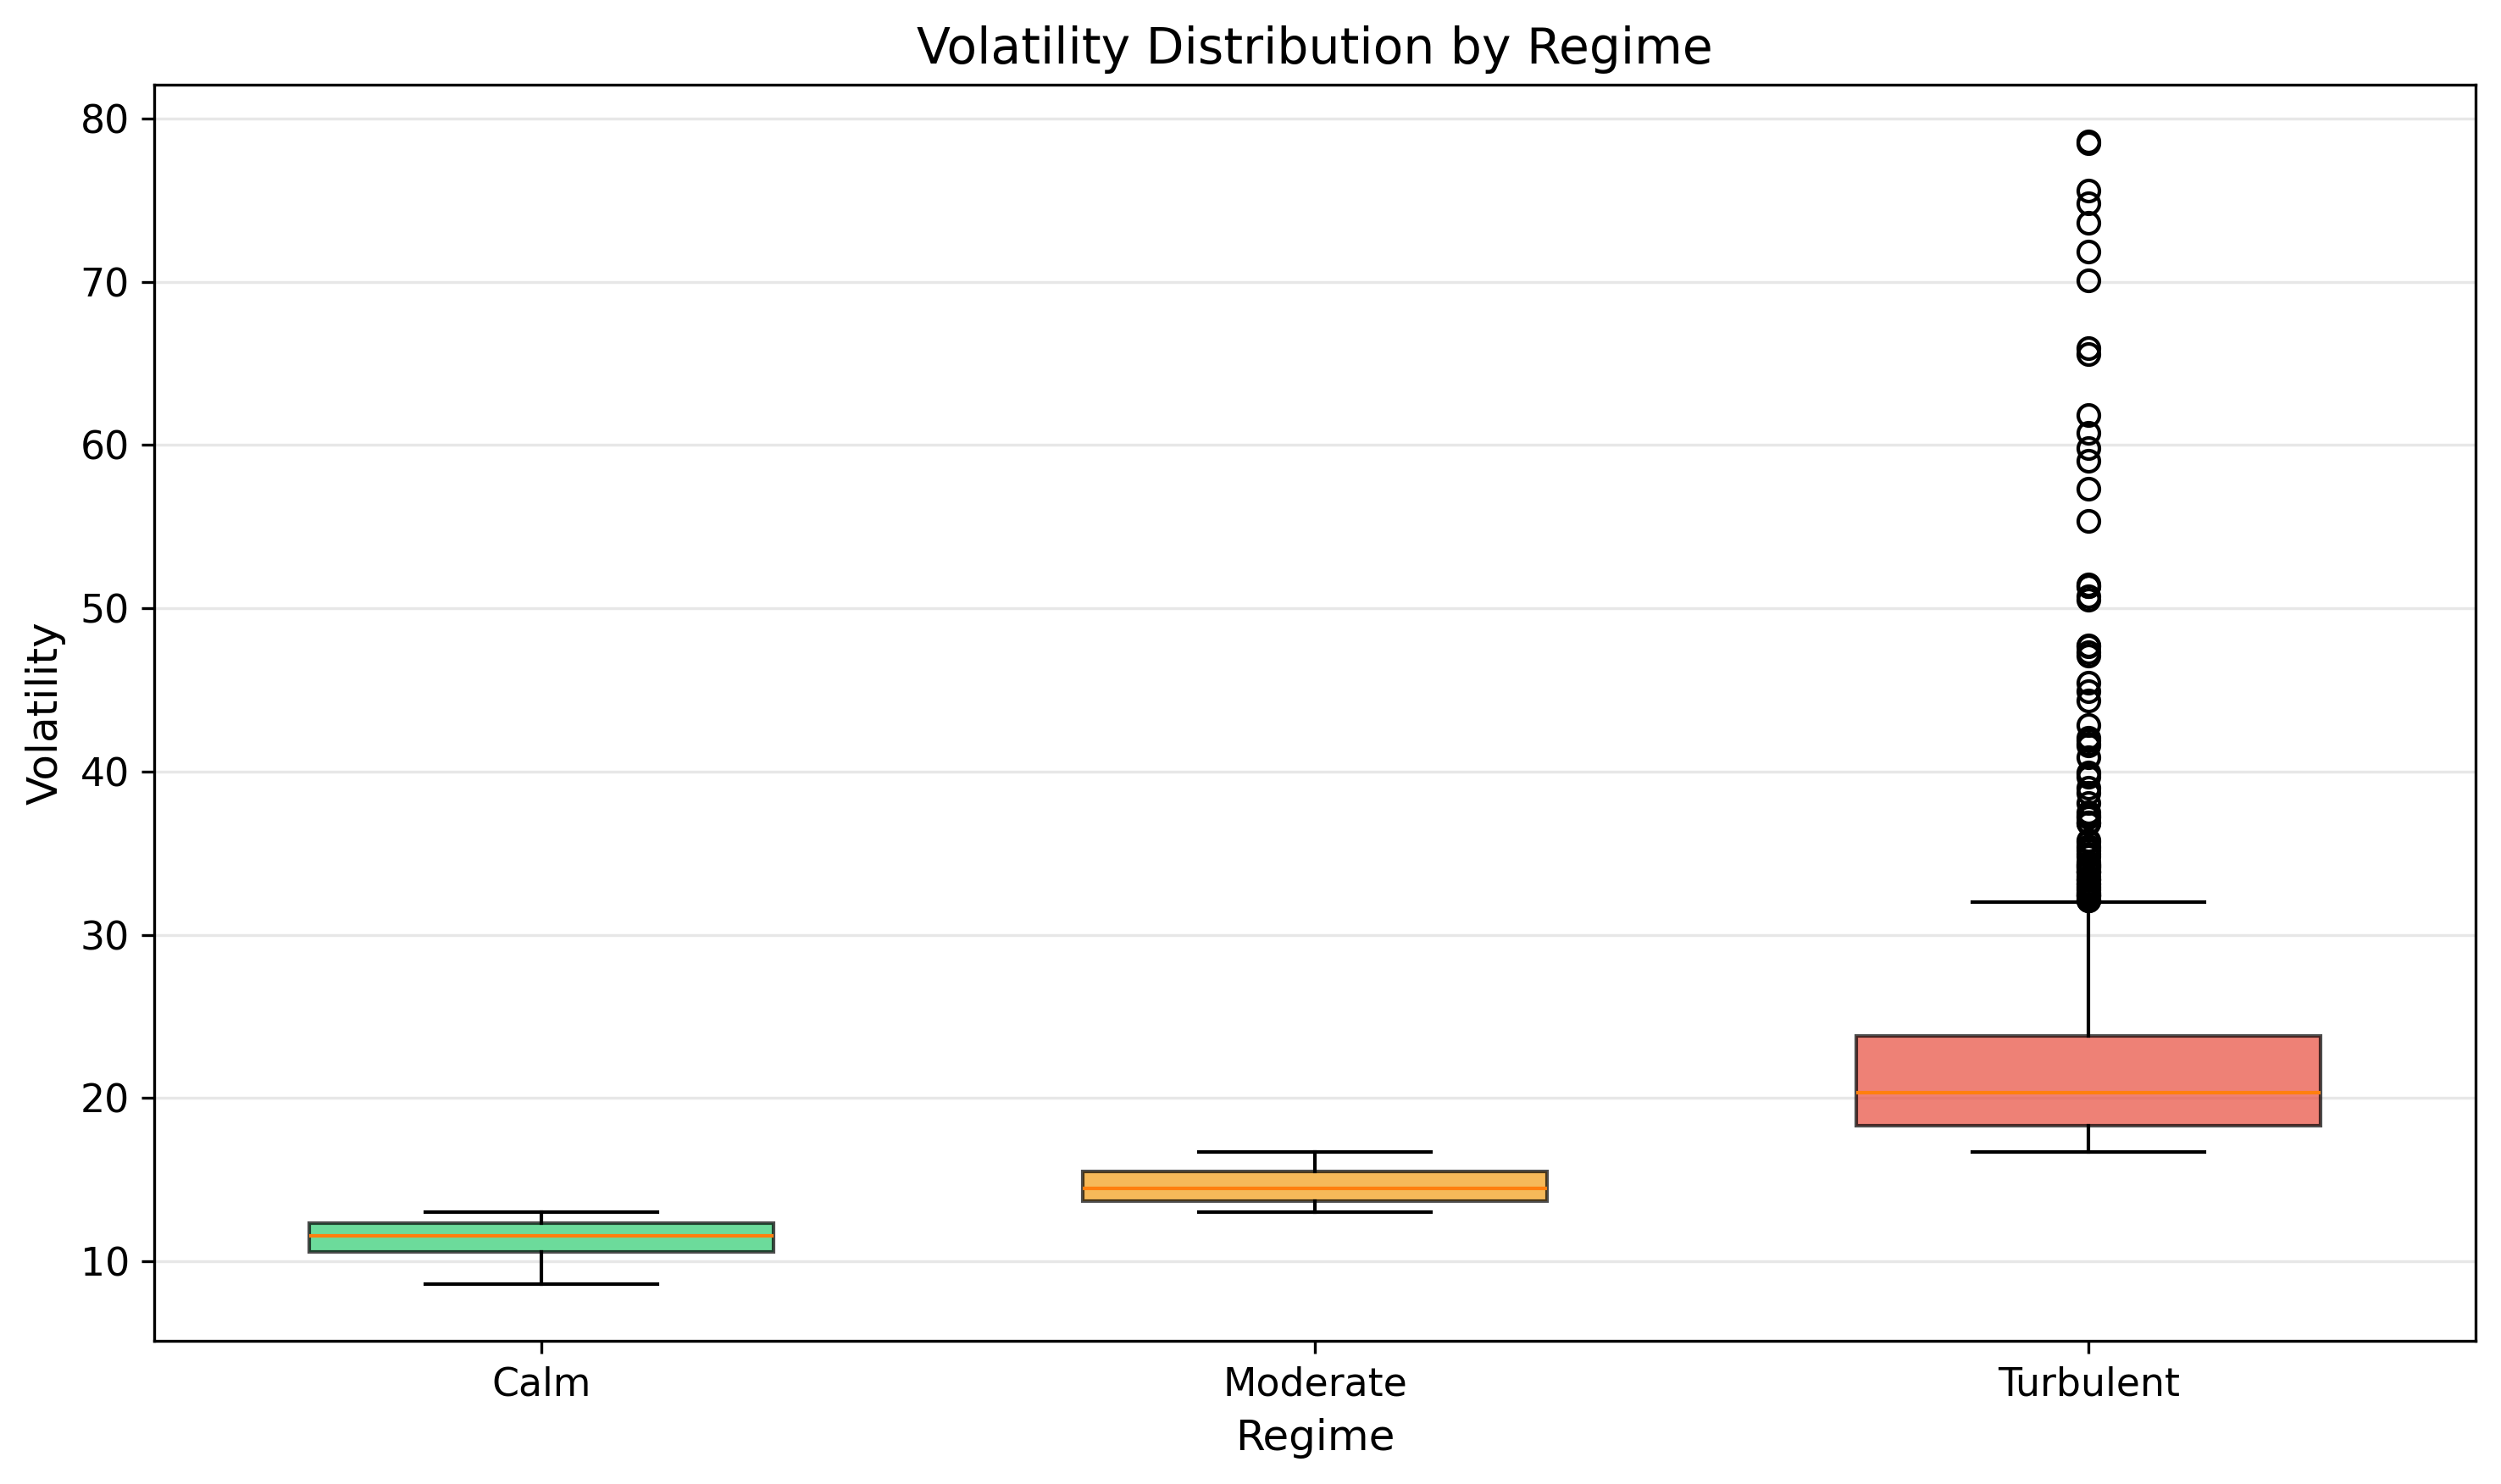

In [61]:
# Define colors for consistency
colors = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}

# Bar chart of regime distribution
plot_regime_distribution_bar(
    regimes=garch_regimes.values,
    regime_labels=regime_labels,
    colors=colors,
    title='GARCH Regime Distribution',
    save_path='../results/figures/garch_regime_distribution_bar.png',
    figsize=(10, 6)
)

# Box plot of volatility by regime
plot_regime_distribution_box(
    volatility=garch_cond_vol.values,
    regimes=garch_regimes.values,
    regime_labels=regime_labels,
    colors=colors,
    title='Volatility Distribution by Regime',
    save_path='../results/figures/garch_regime_distribution_box.png',
    figsize=(10, 6)
)

## 4. 2008 Financial Crisis Deep Dive

Zoom into the 2008 crisis period to validate that GARCH regimes capture market transitions during extreme stress.


### 4.1. Regime Transition Analysis

Analyze regime transitions during the 2008 crisis. 

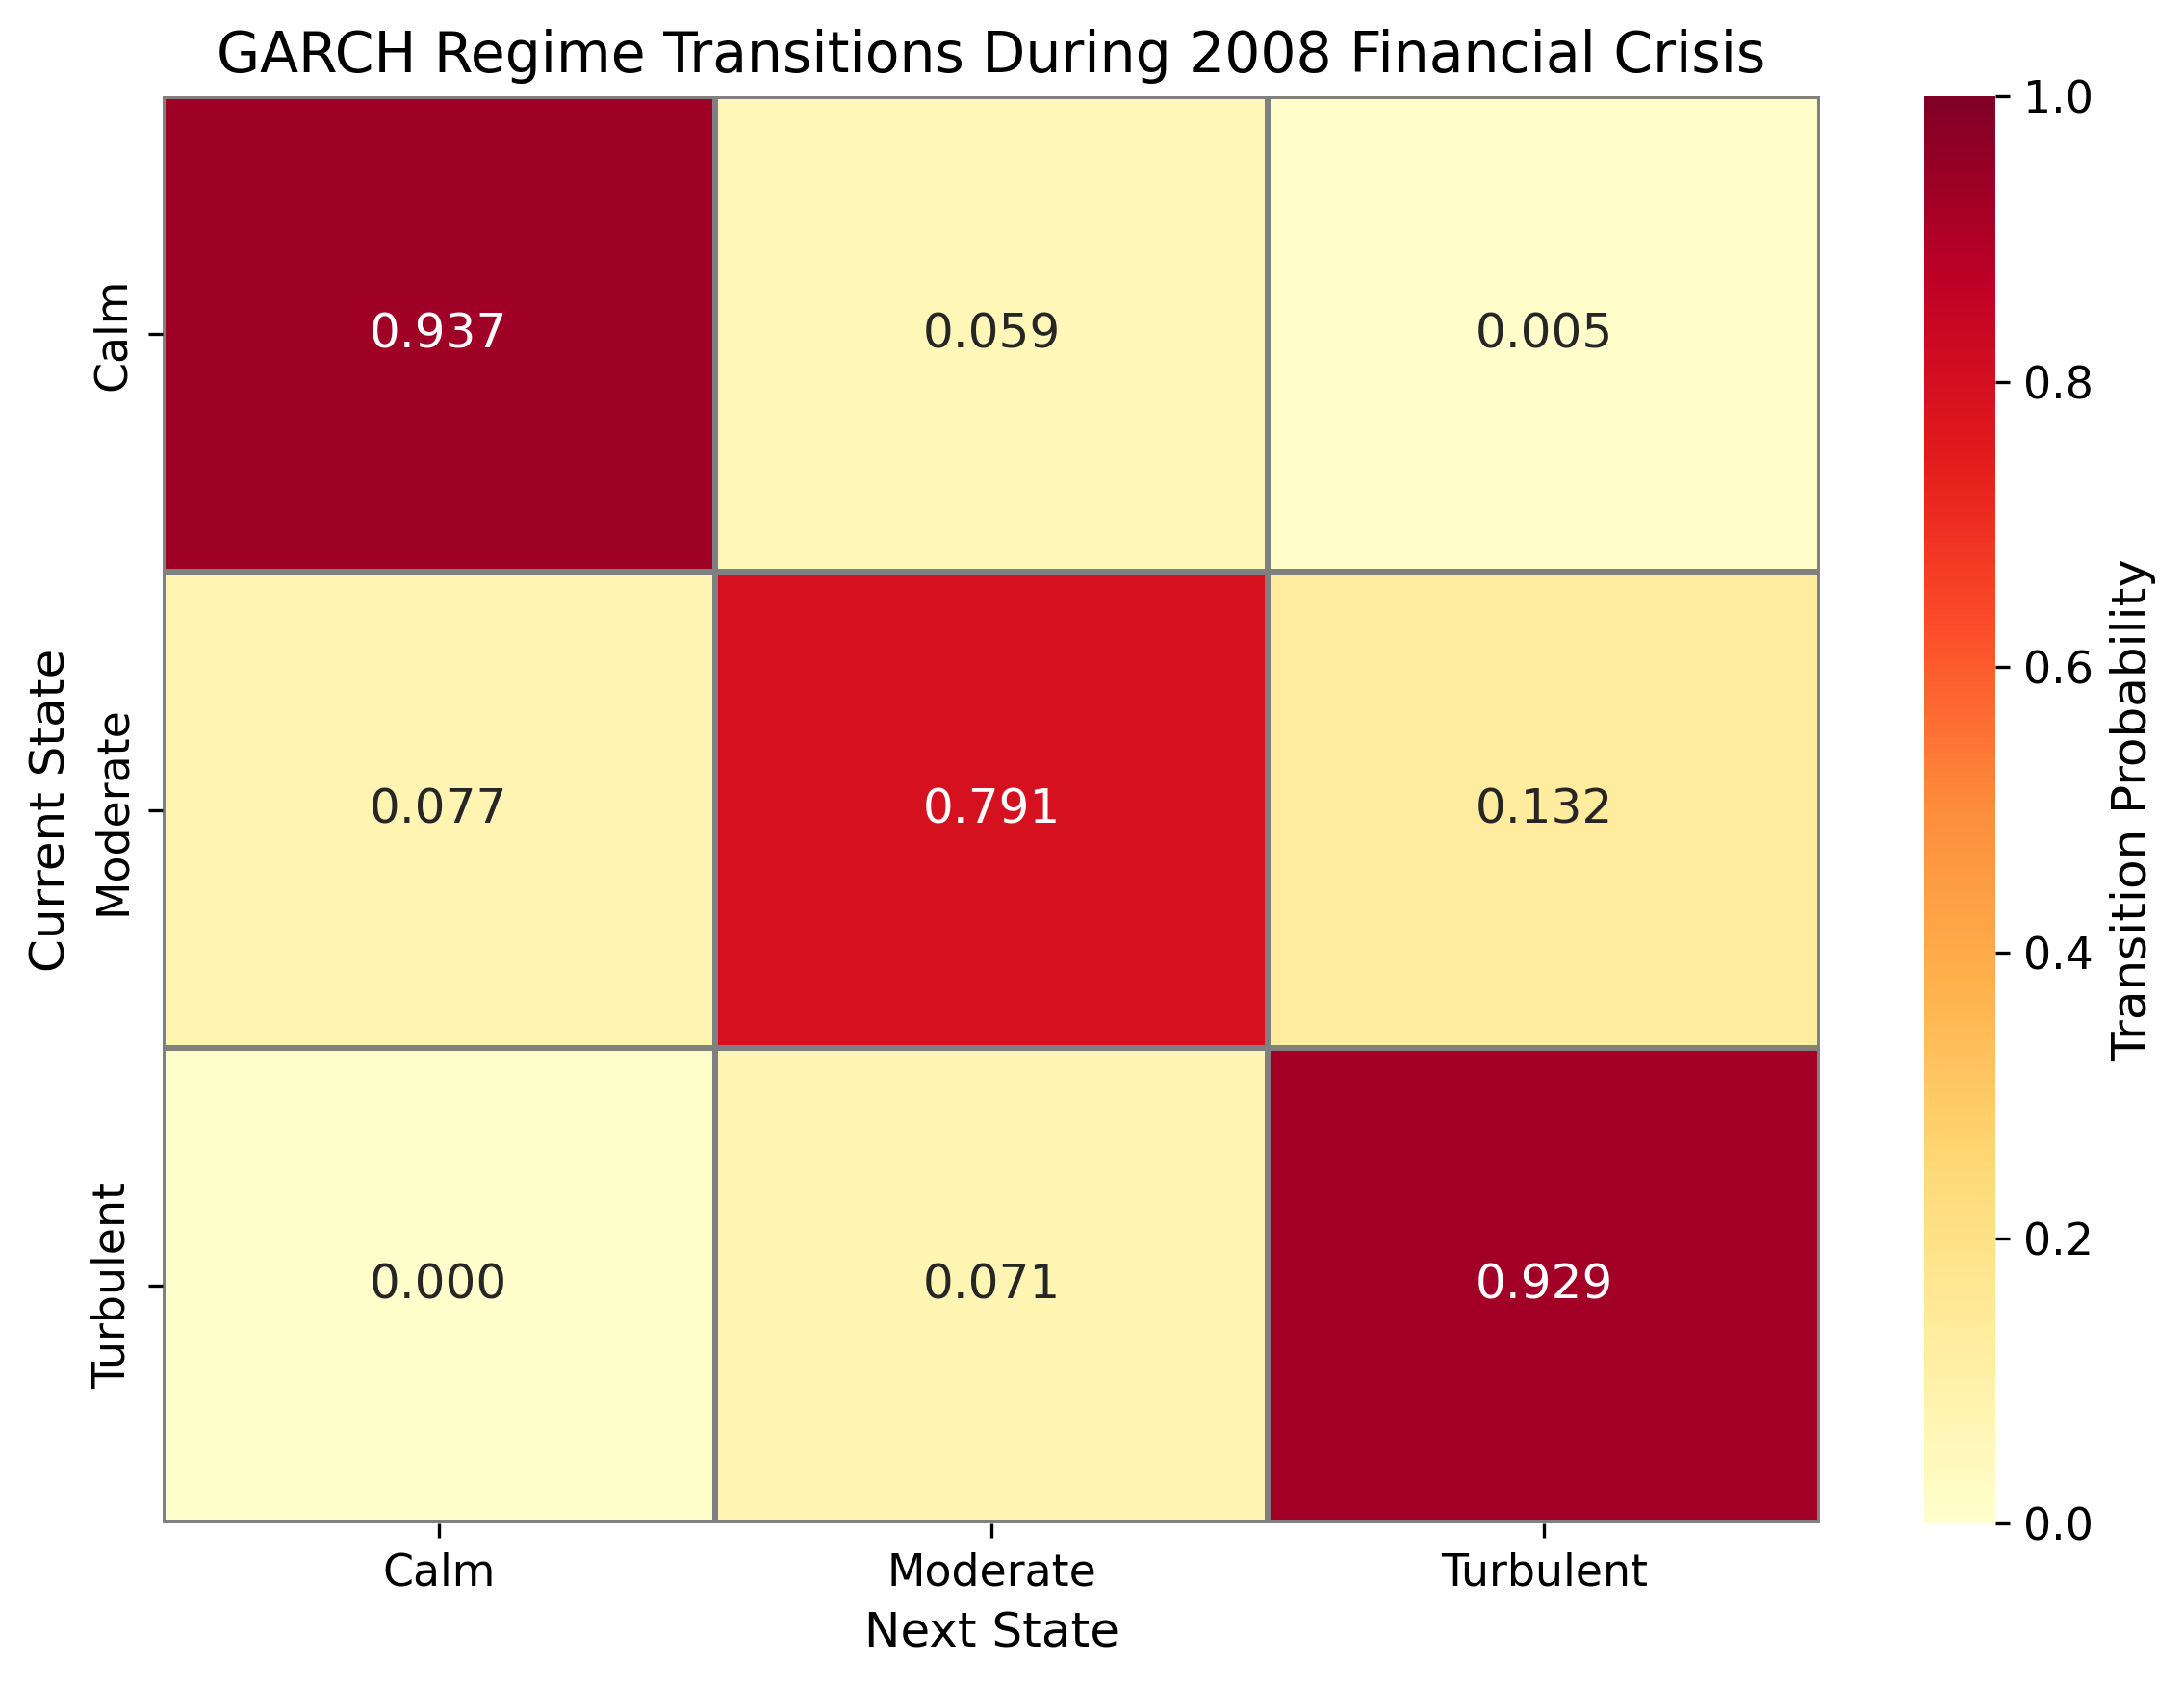

In [62]:
# Filter regimes for 2008 crisis period
crisis_start = '2007-01-01'
crisis_end = '2009-12-31'

crisis_mask = (garch_regimes.index >= crisis_start) & (garch_regimes.index <= crisis_end)
garch_regimes_2008 = garch_regimes[crisis_mask]

# Compute transition matrix
trans_matrix_2008 = compute_transition_matrix(garch_regimes_2008)
metrics_2008 = compute_persistence_metrics(trans_matrix_2008)



# Plot transition matrix
plot_transition_matrix_heatmap(
    transition_matrix=trans_matrix_2008,
    regime_labels=regime_labels,
    title='GARCH Regime Transitions During 2008 Financial Crisis',
    save_path='../results/figures/garch_transition_matrix_2008.png',
    figsize=(8, 6)
)

### 4.2. Crisis Period Visualization

Visualize GARCH regime evolution during the 2008 crisis with key event markers.

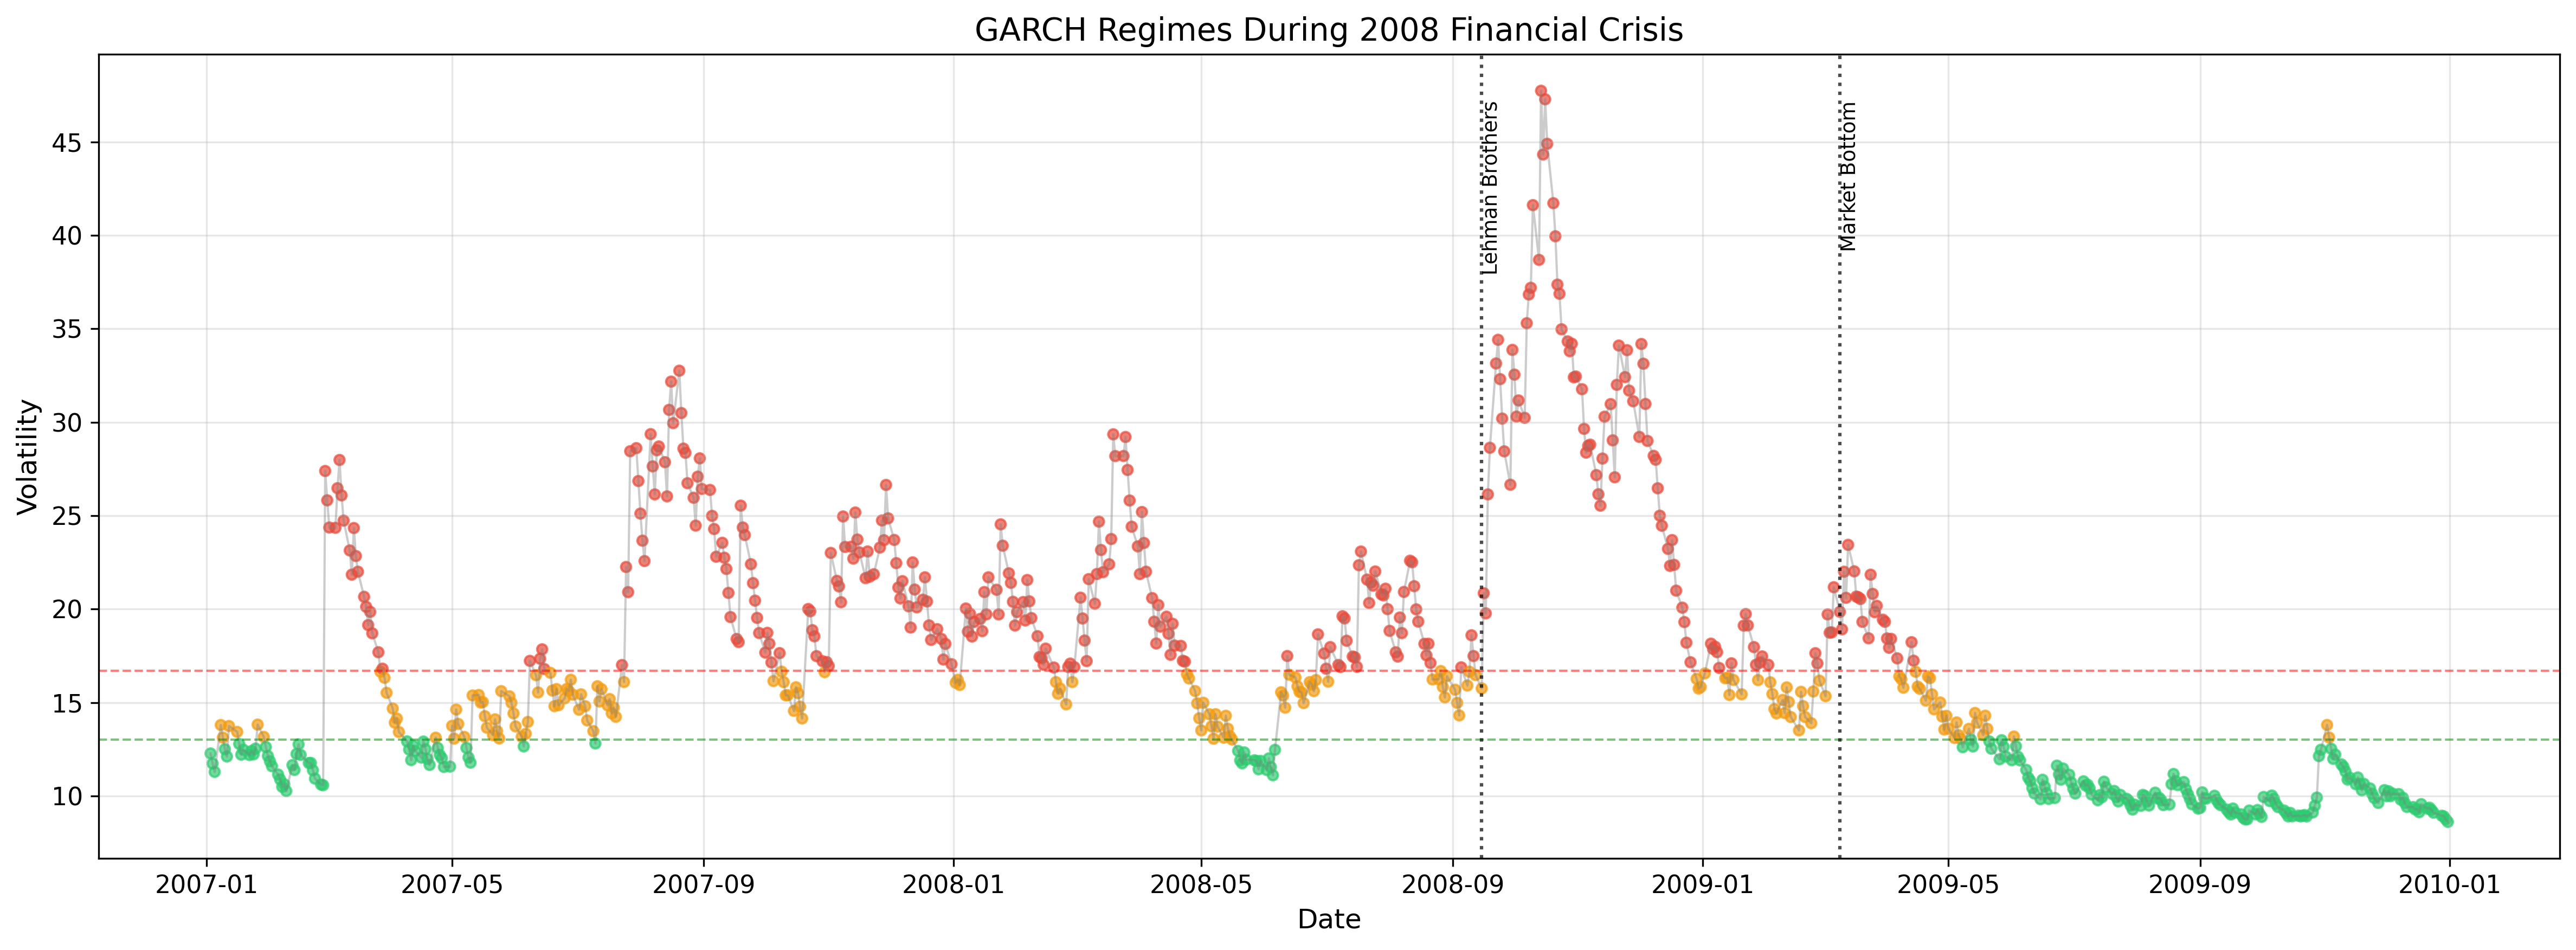

In [63]:
# Define key events during 2008 crisis
events = {
    '2008-09-15': 'Lehman Brothers',
    '2009-03-09': 'Market Bottom'
}

# Plot crisis period
plot_crisis_period(
    dates=garch_regimes.index,
    regimes=garch_regimes.values,
    volatility=garch_cond_vol.values,
    thresholds=thresholds,
    crisis_start='2007-01-01',
    crisis_end='2009-12-31',
    events=events,
    title='GARCH Regimes During 2008 Financial Crisis',
    save_path='../results/figures/garch_crisis_2008.png',
    figsize=(16, 6)
)

## 5. Full Period Regime Analysis (2000-2020)

Comprehensive regime statistics, transition dynamics, and validation across the entire dataset (2000-2020).

### 5.1. Regime Statistics

Compute comprehensive statistics for each regime across the full period (2000-2020).

In [64]:
# Display regime statistics computed in §3.1
print("GARCH Regime Statistics (from quantile classification):")
print(garch_regime_stats.to_string(index=False))


GARCH Regime Statistics (from quantile classification):
   Regime  Count  Percentage      Mean      Std       Min    Median       Max
     Calm   1681   32.999607 11.394321 1.112388  8.615701 11.556832 13.024674
 Moderate   1732   34.000785 14.608063 1.045949 13.025613 14.456807 16.693577
Turbulent   1681   32.999607 22.134771 6.559897 16.702519 20.305167 78.564553


### 5.2. Transition Matrix and Persistence

Analyze regime transition probabilities and compute average regime durations for the full period (2000-2020).

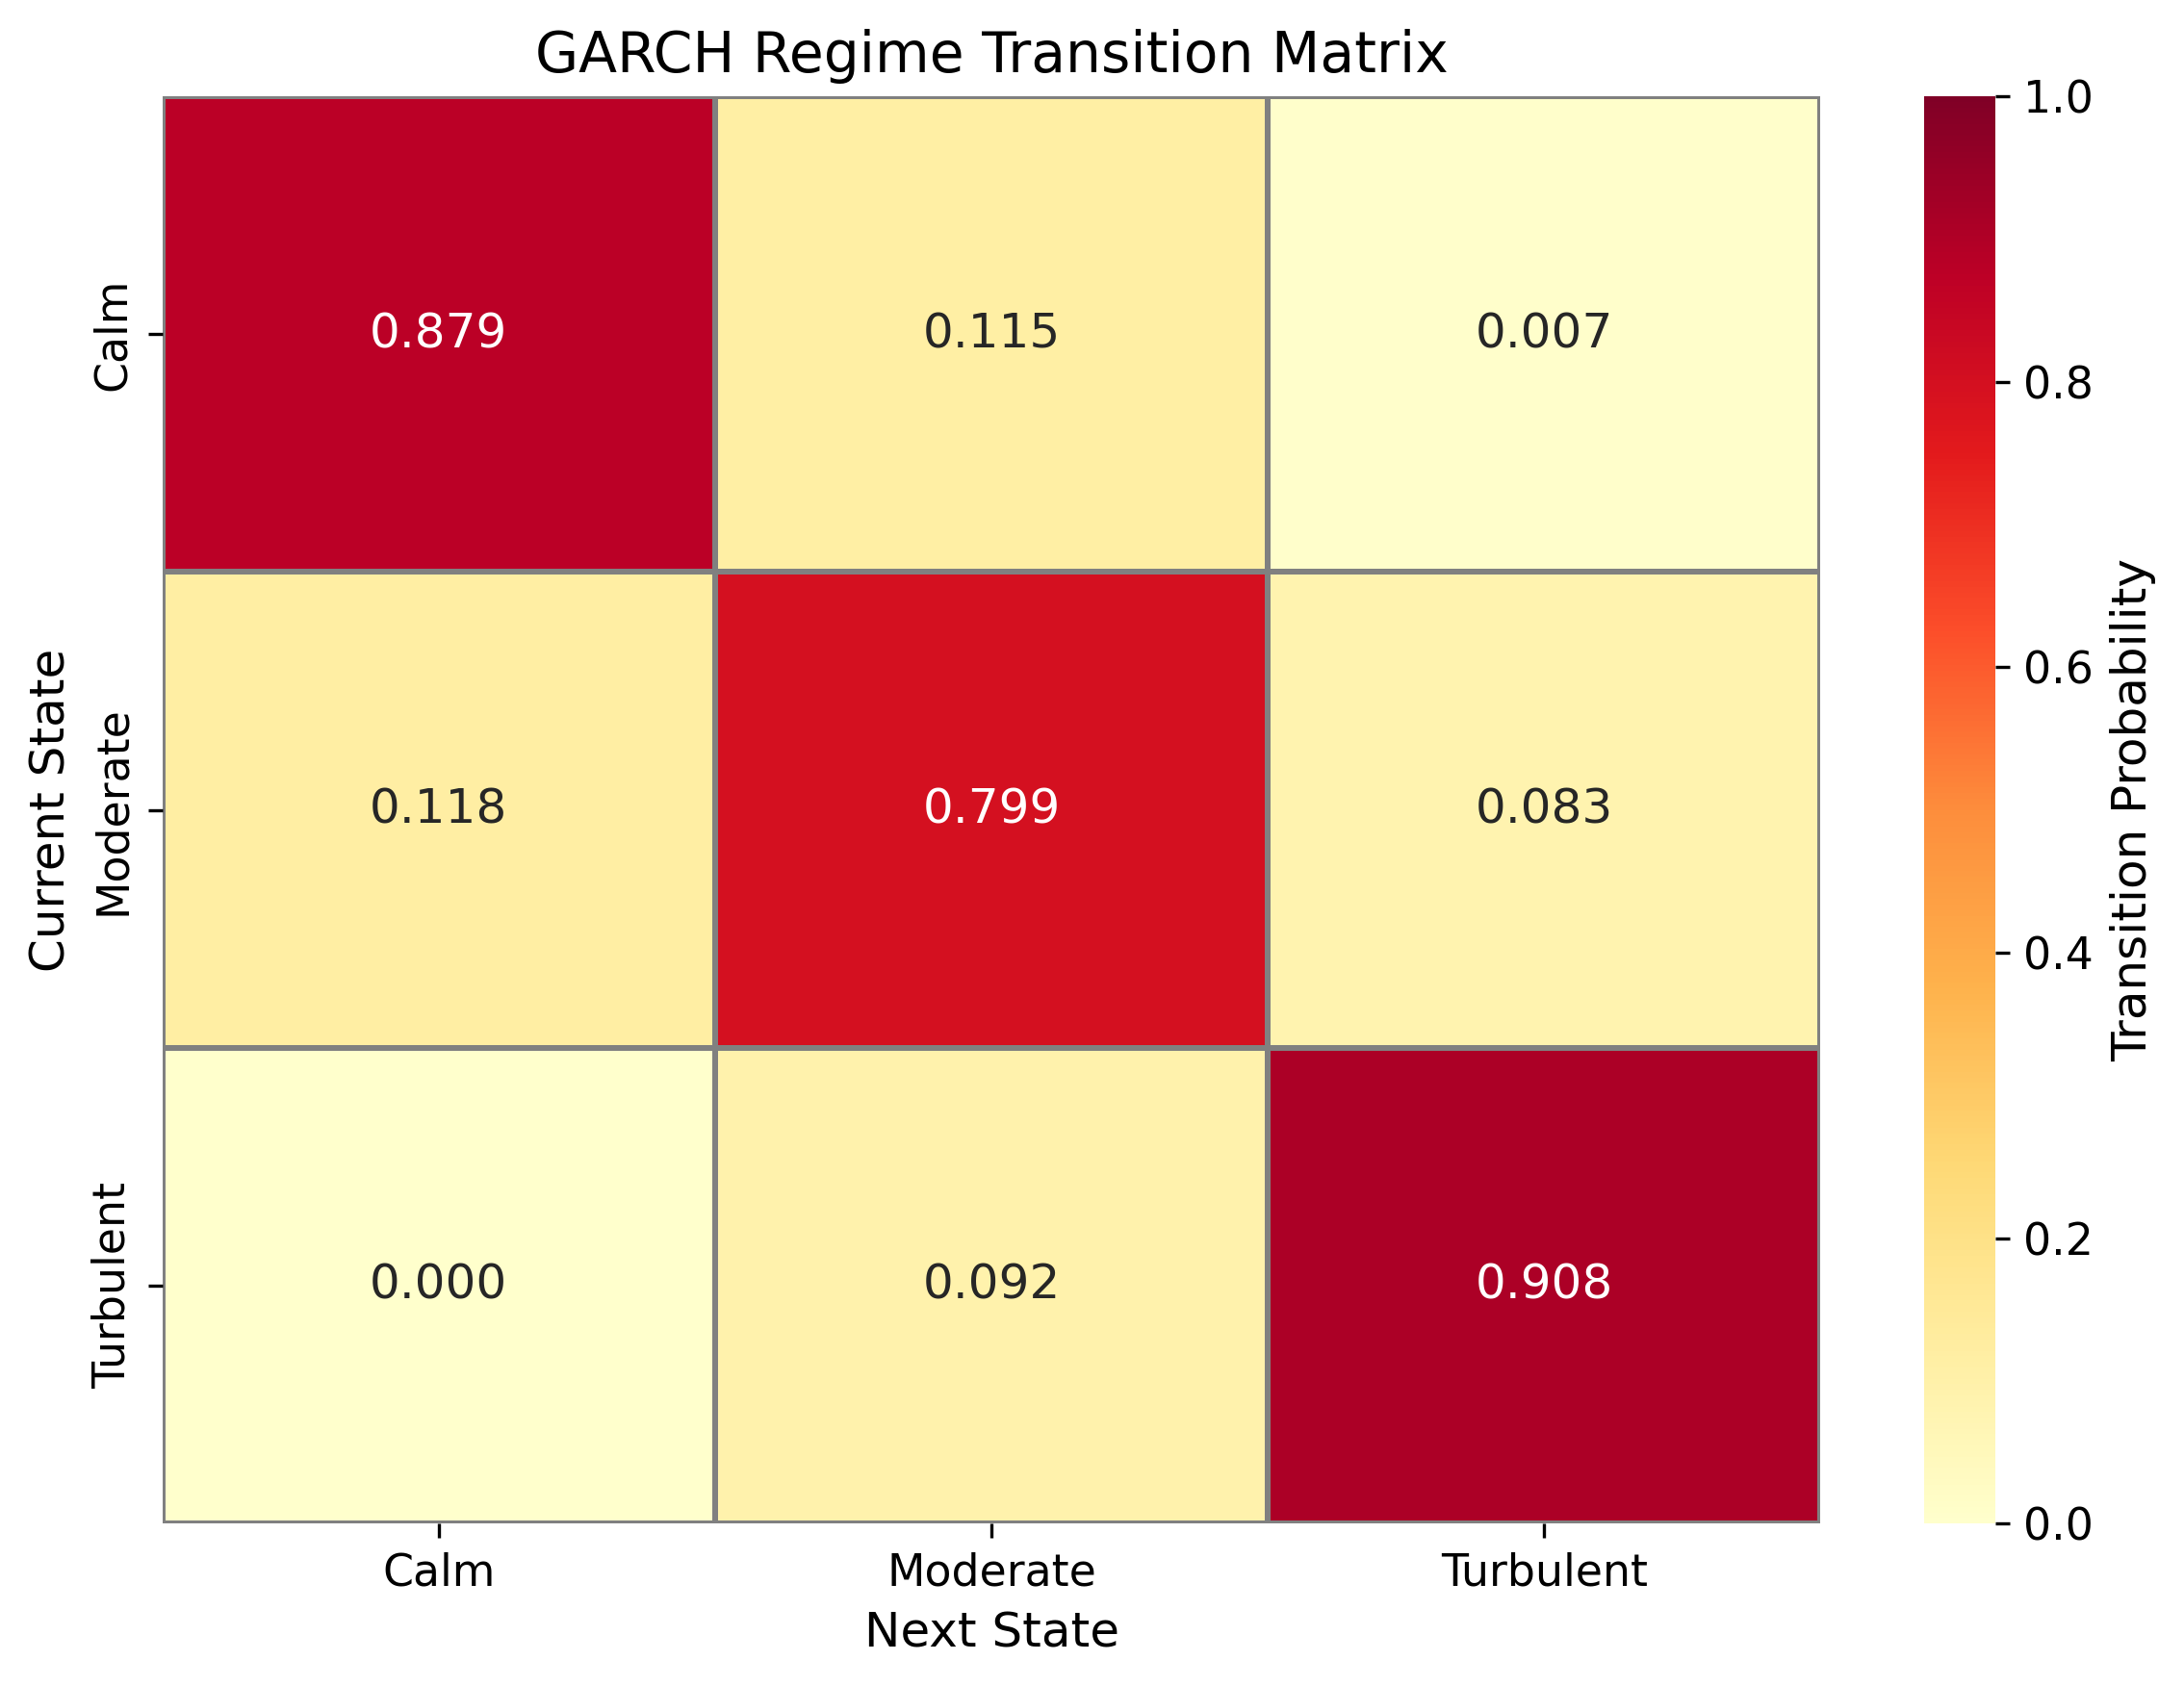

In [65]:
# Compute full period transition matrix
garch_transition_matrix = compute_transition_matrix(garch_regimes)
persistence_metrics = compute_persistence_metrics(garch_transition_matrix)

plot_transition_matrix_heatmap(
    transition_matrix=garch_transition_matrix,
    regime_labels=regime_labels,
    title='GARCH Regime Transition Matrix',
    save_path='../results/figures/garch_transition_matrix.png',
    figsize=(8, 6)
)

### 5.4. Dotcom Bubble Period

Validate GARCH regimes during the 2000-2002 dotcom bubble burst.


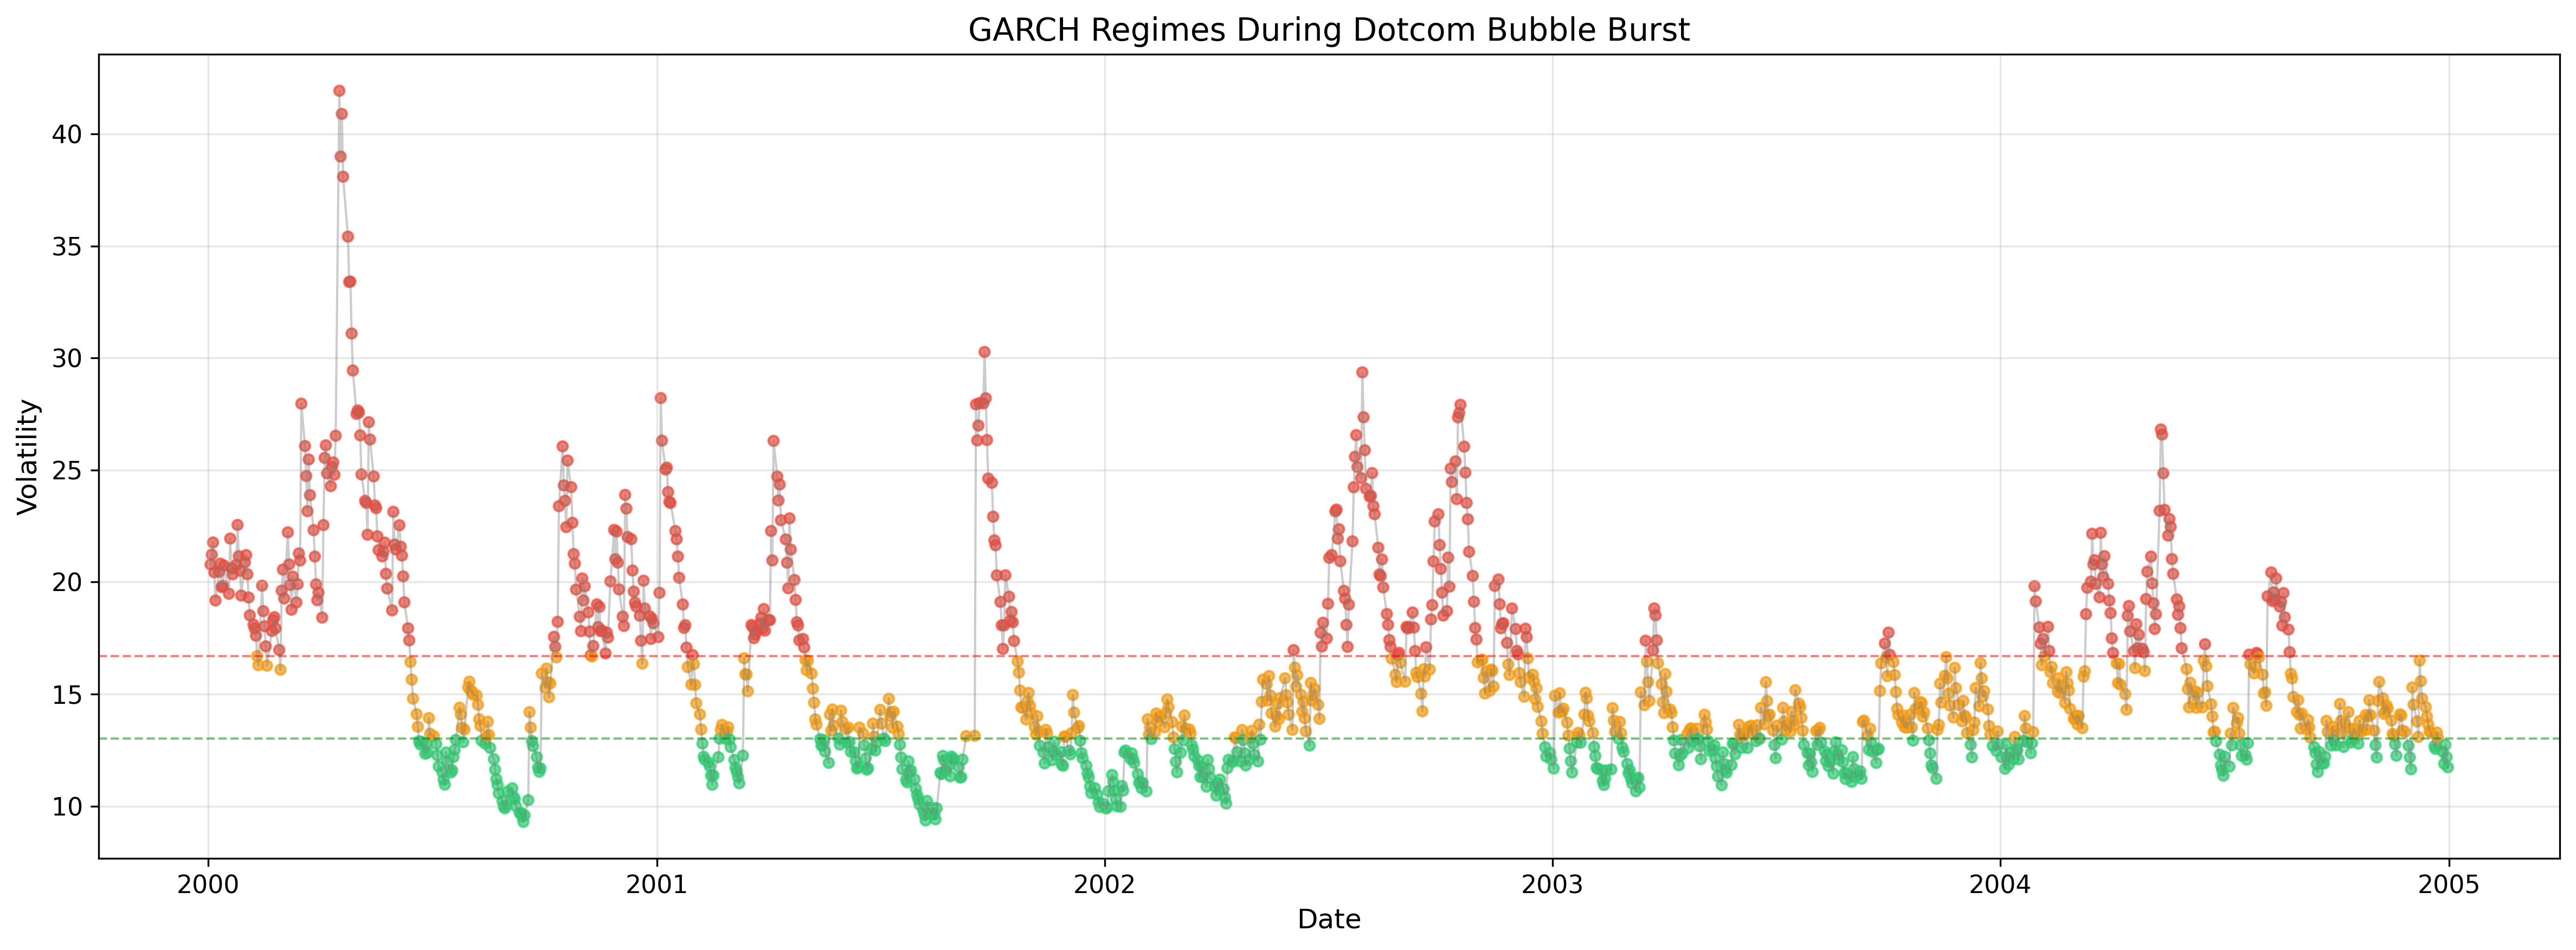

In [66]:
plot_crisis_period(
    dates=garch_regimes.index,
    regimes=garch_regimes.values,
    volatility=garch_cond_vol.values,
    thresholds=thresholds,
    crisis_start='2000-01-01',
    crisis_end='2004-12-31',
    events=None,  # No specific events marked
    title='GARCH Regimes During Dotcom Bubble Burst',
    save_path='../results/figures/garch_crisis_dotcom.png',
    figsize=(16, 6)
)

### 5.5. Save GARCH Regimes for Ensemble Framework

In [67]:
# Save GARCH regimes to CSV for ensemble analysis
# Map regime numbers to their text labels
regime_label_names = garch_regimes.map(lambda x: regime_labels[x])

garch_regimes_df = pd.DataFrame({
    'date': garch_regimes.index,
    'garch_regime': garch_regimes.values,
    'regime_label': regime_label_names.values,
    'conditional_volatility': garch_cond_vol.values
})

output_path = Path('../data/processed/garch_regimes.csv')
garch_regimes_df.to_csv(output_path, index=False)


# Also save transition matrix
garch_trans_df.to_csv('../data/processed/garch_transition_matrix.csv')



## 6. GARCH Volatility Forecasting

Leverage GARCH's unique capabilities to generate forward-looking volatility forecasts.

GARCH Volatility Forecast (Next 30 Days)
   horizon      variance  volatility  volatility_annual
0        1  86067.175645  293.372077          46.571373
1        2  84041.871285  289.899761          46.020160
2        3  82072.000747  286.482112          45.477625
3        4  80156.046772  283.118432          44.943658
4        5  78292.533631  279.808030          44.418148
5        6  76480.025986  276.550223          43.900987
6        7  74717.127787  273.344339          43.392069
7        8  73002.481191  270.189713          42.891287
8        9  71334.765523  267.085689          42.398539
9       10  69712.696254  264.031620          41.913720
...
    horizon      variance  volatility  volatility_annual
25       26  49045.086982  221.461254          35.155884
26       27  48033.099872  219.164550          34.791294
27       28  47048.811468  216.907380          34.432979
28       29  46091.463641  214.689226          34.080858
29       30  45160.319011  212.509574          33.7348

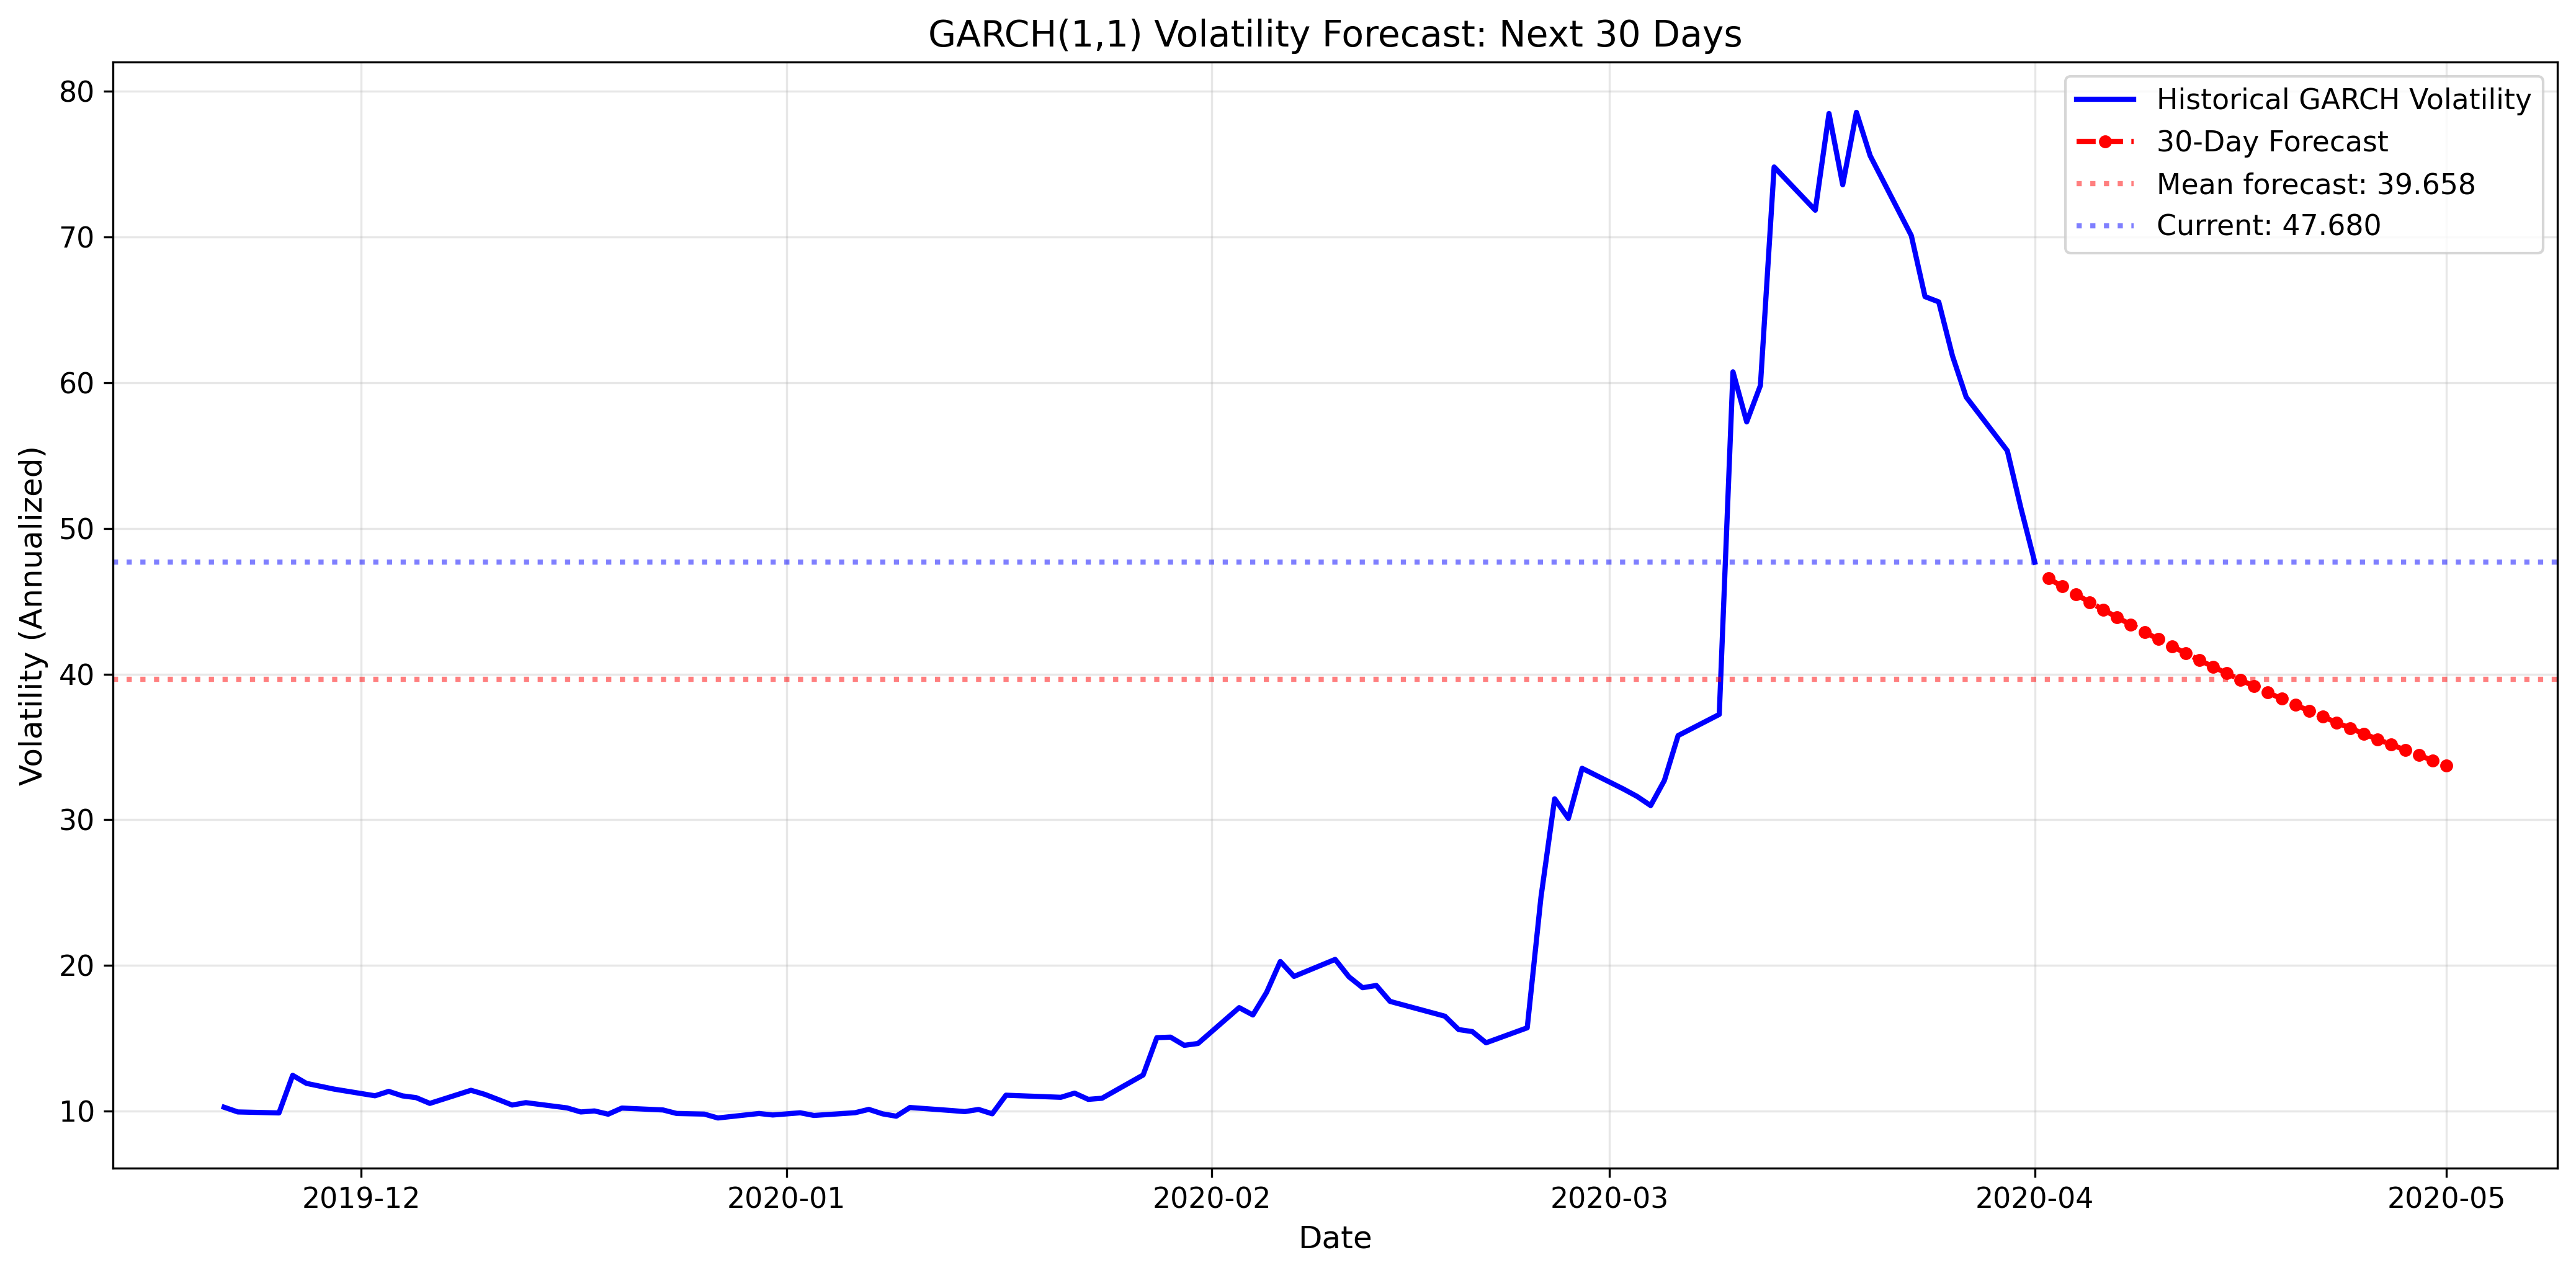


Forecast Summary:
Current volatility:        47.6804
Mean 30-day forecast:      39.6581
Change:                    -16.83%
Long-run mean (omega):     330.4070

Note: GARCH forecasts converge to long-run mean due to mean reversion


In [68]:
# Forecast next 30 days
forecast_df = forecast_volatility(garch_results, horizon=30)

print("GARCH Volatility Forecast (Next 30 Days)")
print(forecast_df.head(10))
print("...")
print(forecast_df.tail(5))

# Plot forecast
fig, ax = plt.subplots(figsize=(14, 7))

# Last 90 days of actual
last_90 = garch_cond_vol.tail(90)
ax.plot(last_90.index, last_90.values, label='Historical GARCH Volatility', 
        color='blue', linewidth=2)

# Forecast
forecast_dates = pd.date_range(start=garch_cond_vol.index[-1] + pd.Timedelta(days=1), 
                                periods=30, freq='D')
ax.plot(forecast_dates, forecast_df['volatility_annual'], 
        label='30-Day Forecast', color='red', linewidth=2, linestyle='--', marker='o', markersize=4)

# Mean forecast line
mean_forecast = forecast_df['volatility_annual'].mean()
ax.axhline(mean_forecast, color='red', linestyle=':', alpha=0.5, linewidth=2,
           label=f'Mean forecast: {mean_forecast:.3f}')

# Current volatility
current_vol = garch_cond_vol.iloc[-1]
ax.axhline(current_vol, color='blue', linestyle=':', alpha=0.5, linewidth=2,
           label=f'Current: {current_vol:.3f}')

ax.set_xlabel('Date')
ax.set_ylabel('Volatility (Annualized)')
ax.set_title('GARCH(1,1) Volatility Forecast: Next 30 Days')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/garch_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nForecast Summary:")
print(f"Current volatility:        {current_vol:.4f}")
print(f"Mean 30-day forecast:      {mean_forecast:.4f}")
print(f"Change:                    {((mean_forecast/current_vol - 1) * 100):.2f}%")
print(f"Long-run mean (omega):     {garch_results.params['omega']:.4f}")
print("\nNote: GARCH forecasts converge to long-run mean due to mean reversion")